# Variables de la distribución normal

In [1]:
import copy
import random
import numpy as np
from scipy.stats import truncnorm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from funciones_utiles import train_LR, create_user_homophily, plot_user_checkpoints, plot_boxplots, User, plot_theta_histogram, error, plot_user_T, error_outcomefl, get_initial_predict_curve, estimate_plot_curves, plot_curves, estimate_base_curve, estimate_plot_curves2
# g1: mu = 0.7, std = 0.15
# g2: mu = 0.3, std = 0.15

# Intervalo de theta y x
a, b = 0, 1

# Media y desviación estándar de grupo 1
mu_g1 = 0.7
std_g1 = 0.15
a_g1 = (a - mu_g1) / std_g1
b_g1 = (b - mu_g1) / std_g1

# Media y desviación estándar de grupo 2
mu_g2 = 0.3
std_g2 = 0.15
a_g2 = (a - mu_g2) / std_g2
b_g2 = (b - mu_g2) / std_g2

# Creación de dataset sintético inicial

In [2]:
# Creación de dataset sintético inicial para entrenar el modelo

X = []
Y = []

# Meto muestras pertenecientes a G1
for i in range(500):
    x = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    y = np.random.binomial(1, x)
    X.append(x)
    Y.append(y)

for i in range(500):
    x = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    y = np.random.binomial(1, x)
    X.append(x)
    Y.append(y)
    
# guardo los X e y iniciales para las simulaciones siguientes
X = np.array(X).reshape(-1, 1)
y = np.array(Y)
print(X.shape, y.shape)

X_start = copy.deepcopy(X)
y_start = copy.deepcopy(y)

(1000, 1) (1000,)


# Creación de dataset sintético ruidoso inicial

In [3]:
# Creación de dataset sintético inicial para entrenar el modelo (y con ruido)

X = []
Y = []

# Meto muestras pertenecientes a G1
for i in range(500):
    x = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    x_error = truncnorm.rvs((0-x)/1, (1-x)/1, loc=x, scale=1)
    y = np.random.binomial(1, x_error)
    X.append(x)
    Y.append(y)

for i in range(500):
    x = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    x_error = truncnorm.rvs((0-x)/1, (1-x)/1, loc=x, scale=1)
    y = np.random.binomial(1, x_error)
    X.append(x)
    Y.append(y)

# guardo los X e y iniciales ruidosos para las simulaciones siguientes
X = np.array(X).reshape(-1, 1)
y = np.array(Y)
print(X.shape, y.shape)

X_noisy_start = copy.deepcopy(X)
y_noisy_start = copy.deepcopy(y)

(1000, 1) (1000,)


# Entrenamiento del modelo inicial

In [4]:
# Entreno logistic regression inicial
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)

# Separar entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Crear y entrenar modelo
model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
#print("Probabilidades estimadas:", y_prob)

Accuracy: 0.69
Matriz de confusión:
[[106  42]
 [ 51 101]]


In [5]:
# hago una copia del modelo inicial para futuras simulaciones
initial_model = copy.deepcopy(model)

# Entrenamiento del modelo ruidoso inicial

In [6]:
# Entreno logistic regression inicial
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)

# Separar entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Crear y entrenar modelo
noisy_model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
noisy_model.fit(X_train, y_train)

# Predicción
y_pred = noisy_model.predict(X_test)
y_prob = noisy_model.predict_proba(X_test)[:, 1]

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
#print("Probabilidades estimadas:", y_prob)

Accuracy: 0.5433333333333333
Matriz de confusión:
[[65 81]
 [56 98]]


In [7]:
# hago una copia del modelo inicial para futuras simulaciones
initial_noisy_model = copy.deepcopy(noisy_model)

# Creación de población de usuarios inicial

In [8]:
# Una vez entrenado el modelo inicial, creo población de usuarios
n = 1000
population = []

"""
for i in range(n):
    p = np.random.binomial(1, 0.5)

    if p == 0:
        group = 1
        theta = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
        x = theta
    else:
        group = 2
        theta = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
        x = theta

    user = User(i, group, theta, x)
    population.append(user)
"""
for i in range(0, 500):
    group= 1
    theta = truncnorm.rvs(a_g1, b_g1, loc=mu_g1, scale=std_g1)
    x = theta
    
    user = User(i, group, theta, x)
    population.append(user)

for i in range(0, 500):
    group= 2
    theta = truncnorm.rvs(a_g2, b_g2, loc=mu_g2, scale=std_g2)
    x = theta
    
    user = User(i, group, theta, x)
    population.append(user)



In [9]:
# copio la poblacion inicial para reproducibilidad en 
# siguientes experimentos 
initial_population = copy.deepcopy(population)

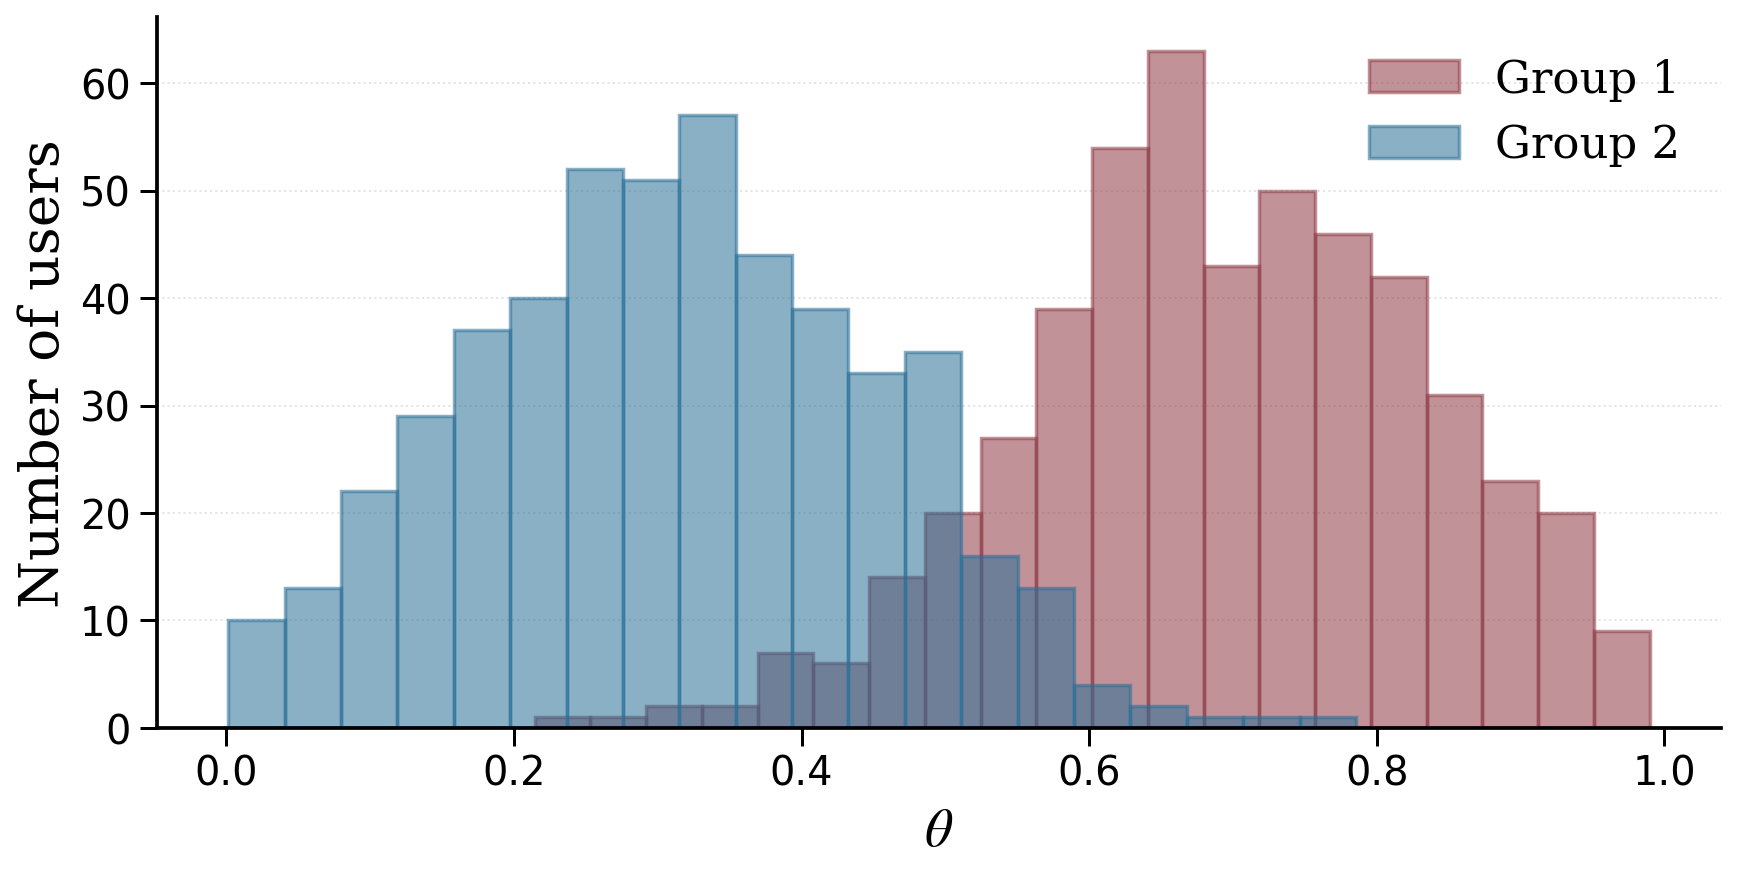

In [10]:
# graficos distribución de interés de la población inicial
plot_theta_histogram(initial_population)

# Sampling Feedback Loop (normal)

In [11]:
# Simulación de sampling FL

X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []

# Inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x

    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
            
    # consecuencias de la decision (quitar usuario, meter uno nuevo)
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        else:
            n_g2 -= 1
        new_user = create_user_homophily(user_id, n_g1, n_g2)
        population.append(new_user)
        if new_user.group == 1:
            n_g1 += 1
        else:
            n_g2 += 1
            
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
        
    # añadir x,y al dataset
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [12]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

939 61
757 49244


In [13]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

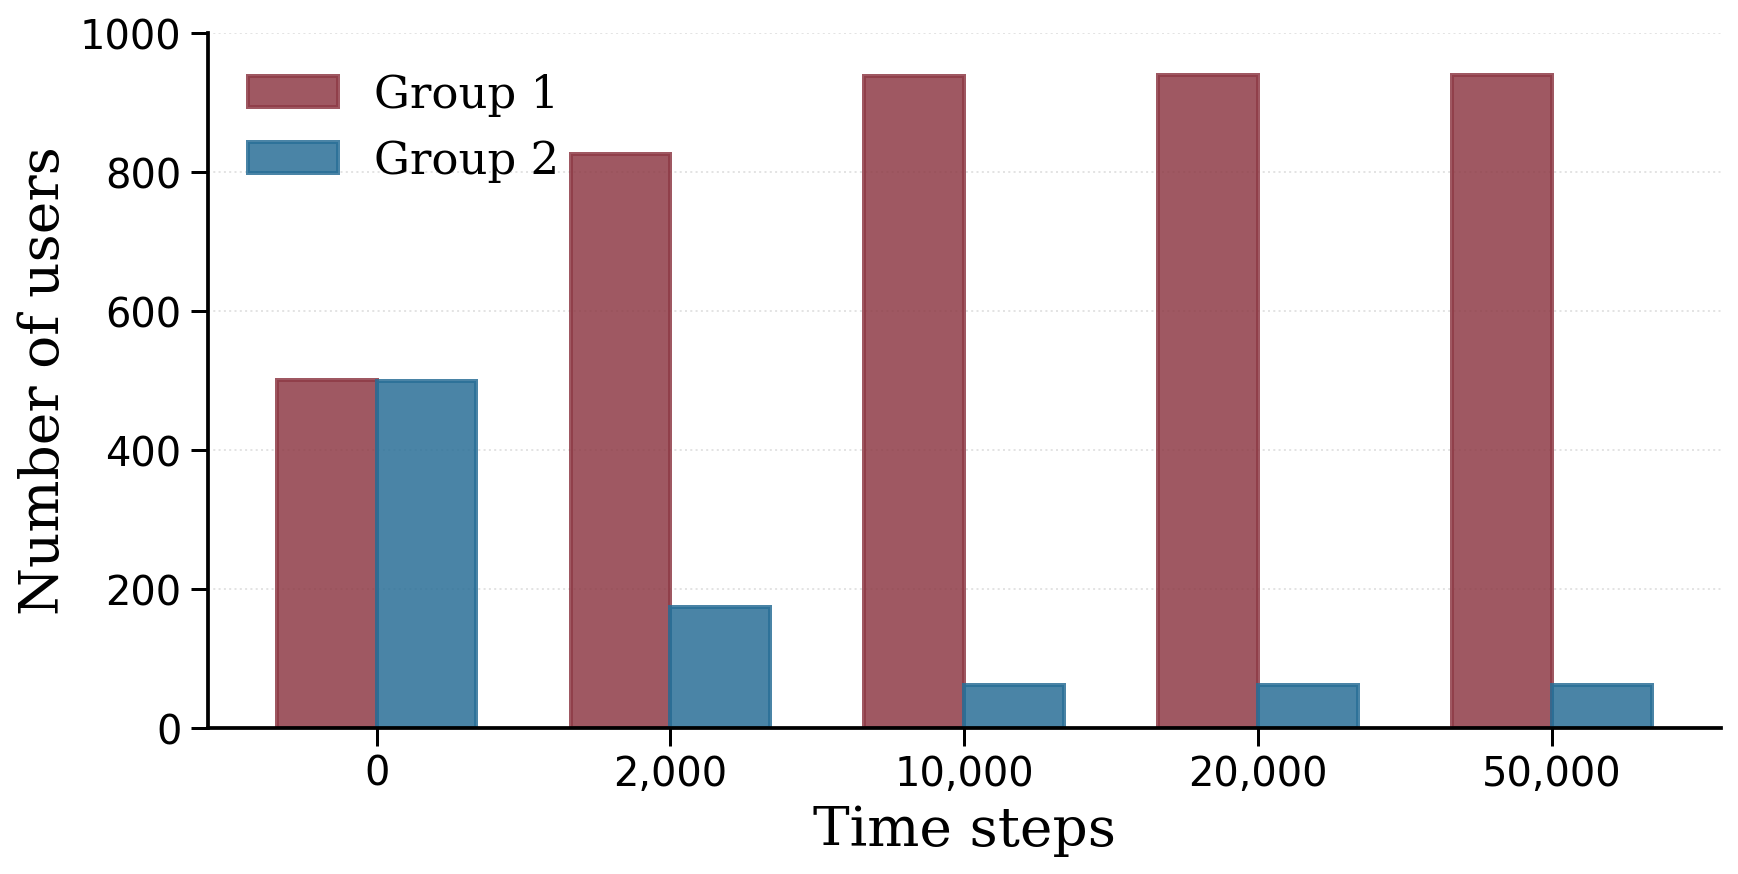

In [14]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

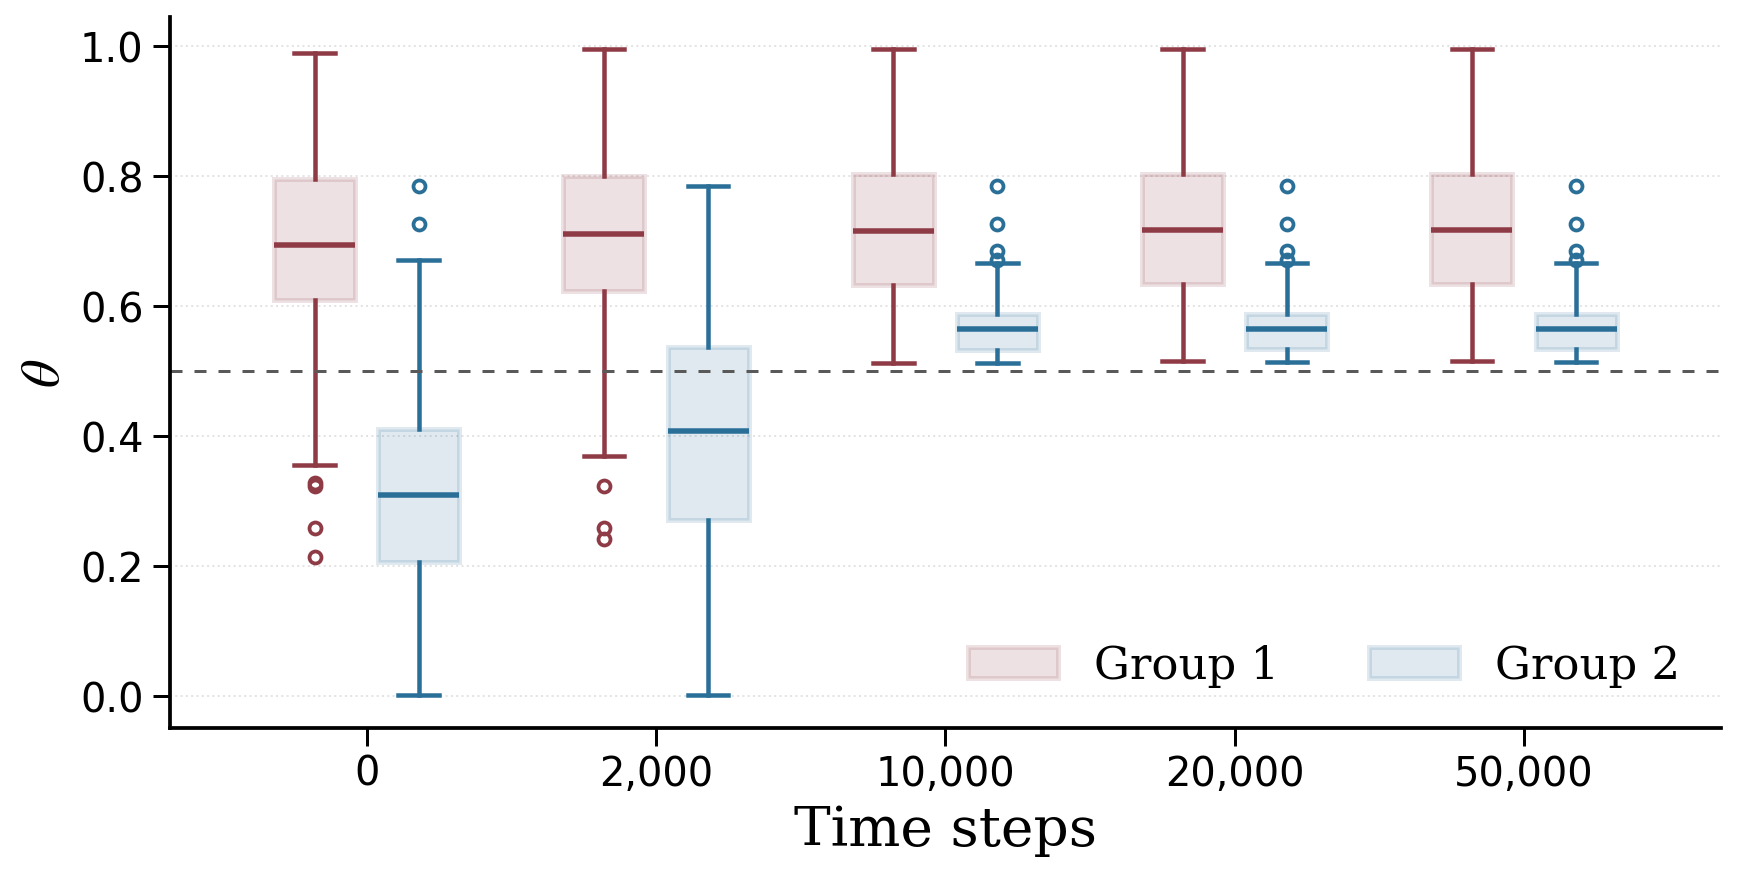

In [15]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "lower right")

# Sampling Feedback Loop (threshold de decision diferente)

In [16]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [17]:
# Simulación de sampling FL threshold diferente

T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []

# Inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x

    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision (único cambio aquí)
    #y_hat = model.predict([[x]])[0]
    #d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    y_hat = model.predict_proba([[x]])[0,1]
    d = 1 if y_hat > 0.65 else 0
            
    # consecuencias de la decision (quitar usuario, meter uno nuevo)
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        else:
            n_g2 -= 1
        new_user = create_user_homophily(user_id, n_g1, n_g2)
        population.append(new_user)
        if new_user.group == 1:
            n_g1 += 1
        else:
            n_g2 += 1
            
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
        
    # añadir x,y al dataset
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [18]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

995 5
1423 48578


In [19]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

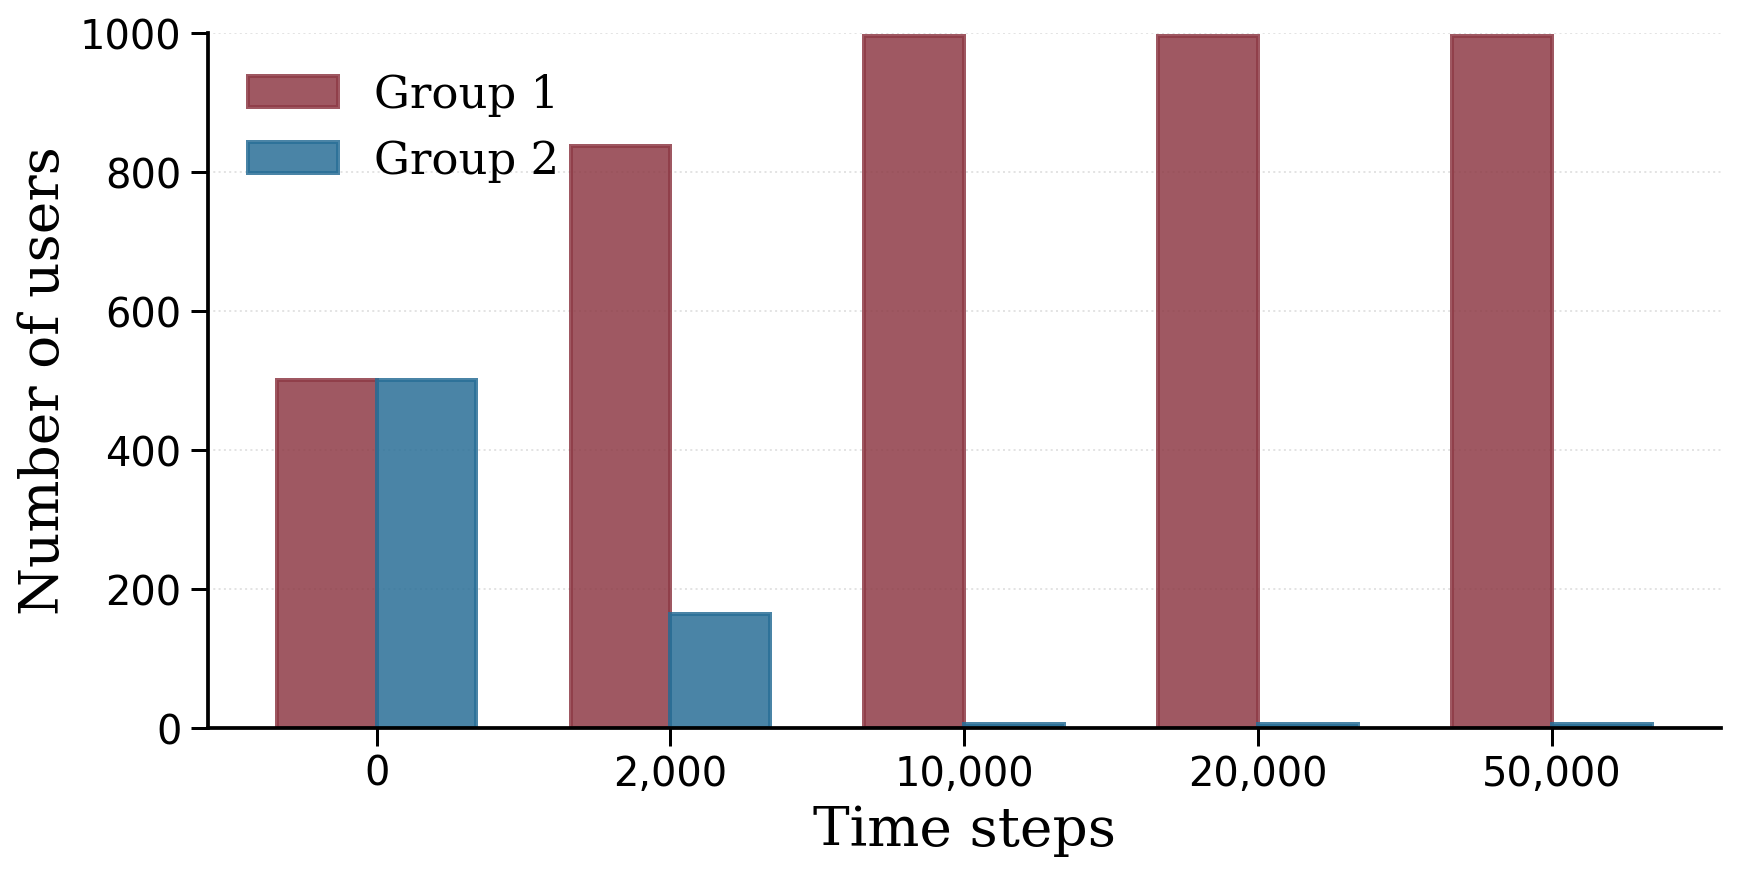

In [20]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

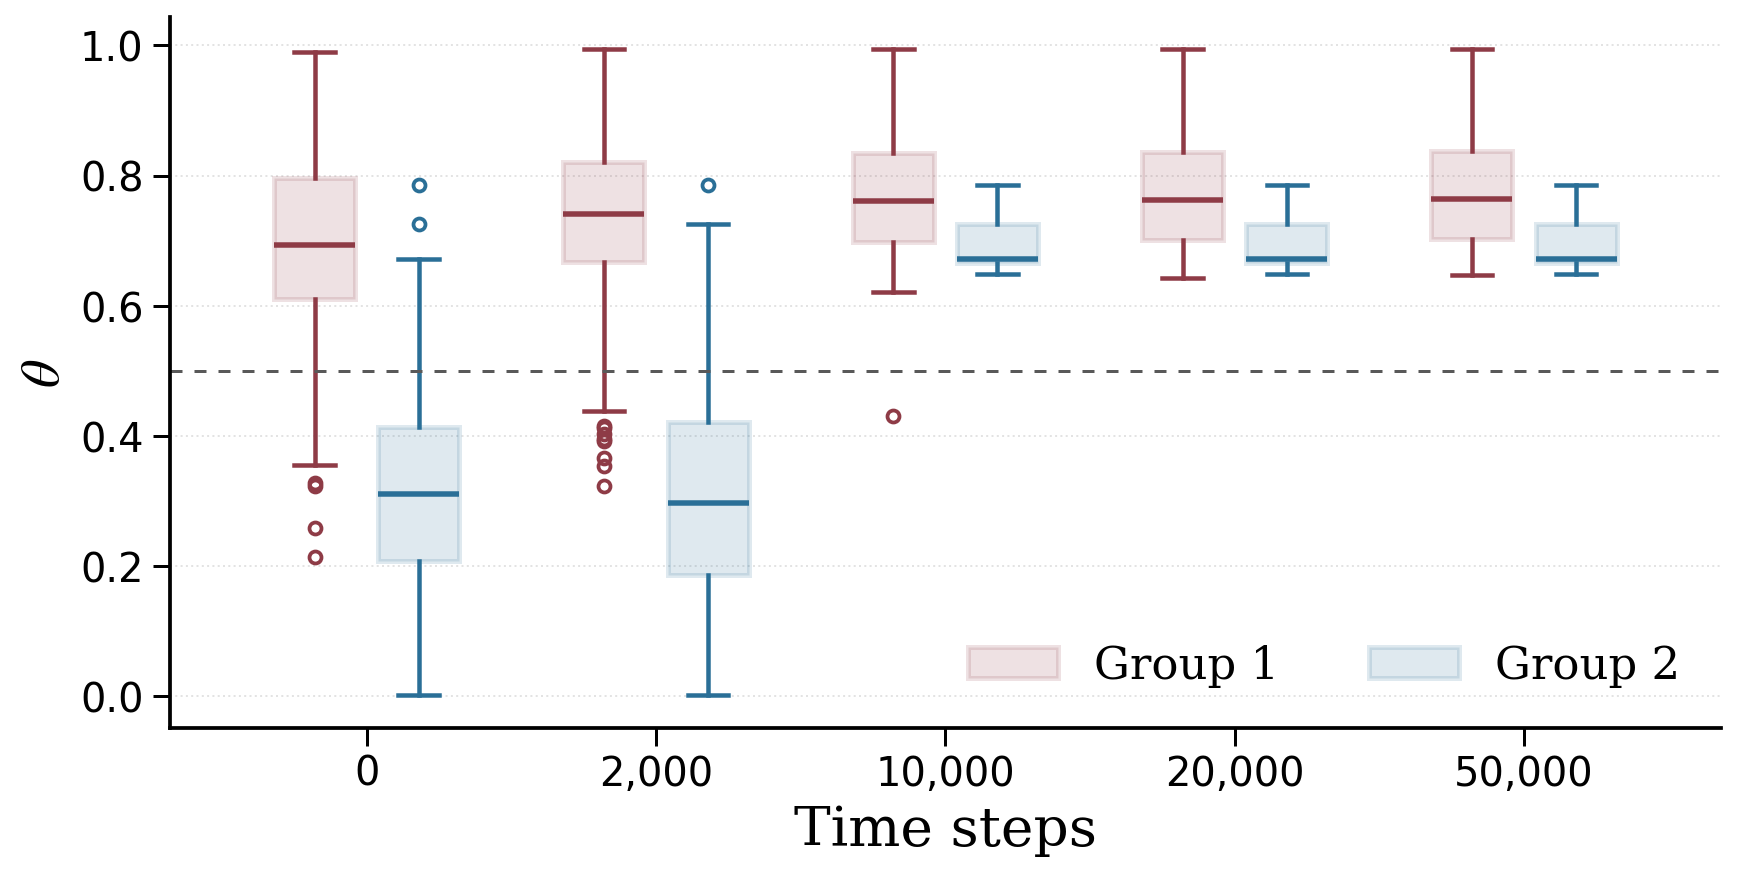

In [21]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "lower right")

# ML Model Feedback Loop

Para este caso usamos el dataset inicial ruidoso, y por tanto el modelo inicial ruidoso.. La población de inicio es initial_population, el mismo para todas las simulaciones 

In [22]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [23]:
# Simulación de ML Mode FL
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

error_T_g1 = {}
error_T_g2 = {}

# Variables que creo para análsis
count_d1 = 0
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5

    
    # consecuencias de la decision (solo se añade el par x,y si d=1)
    if d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
    
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
    
    count_d1 += (d == 1)    #test
    count_d0 += (d == 0)
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2

In [24]:
# variables de análsis
print(count_d0, count_d1)

22673 27328


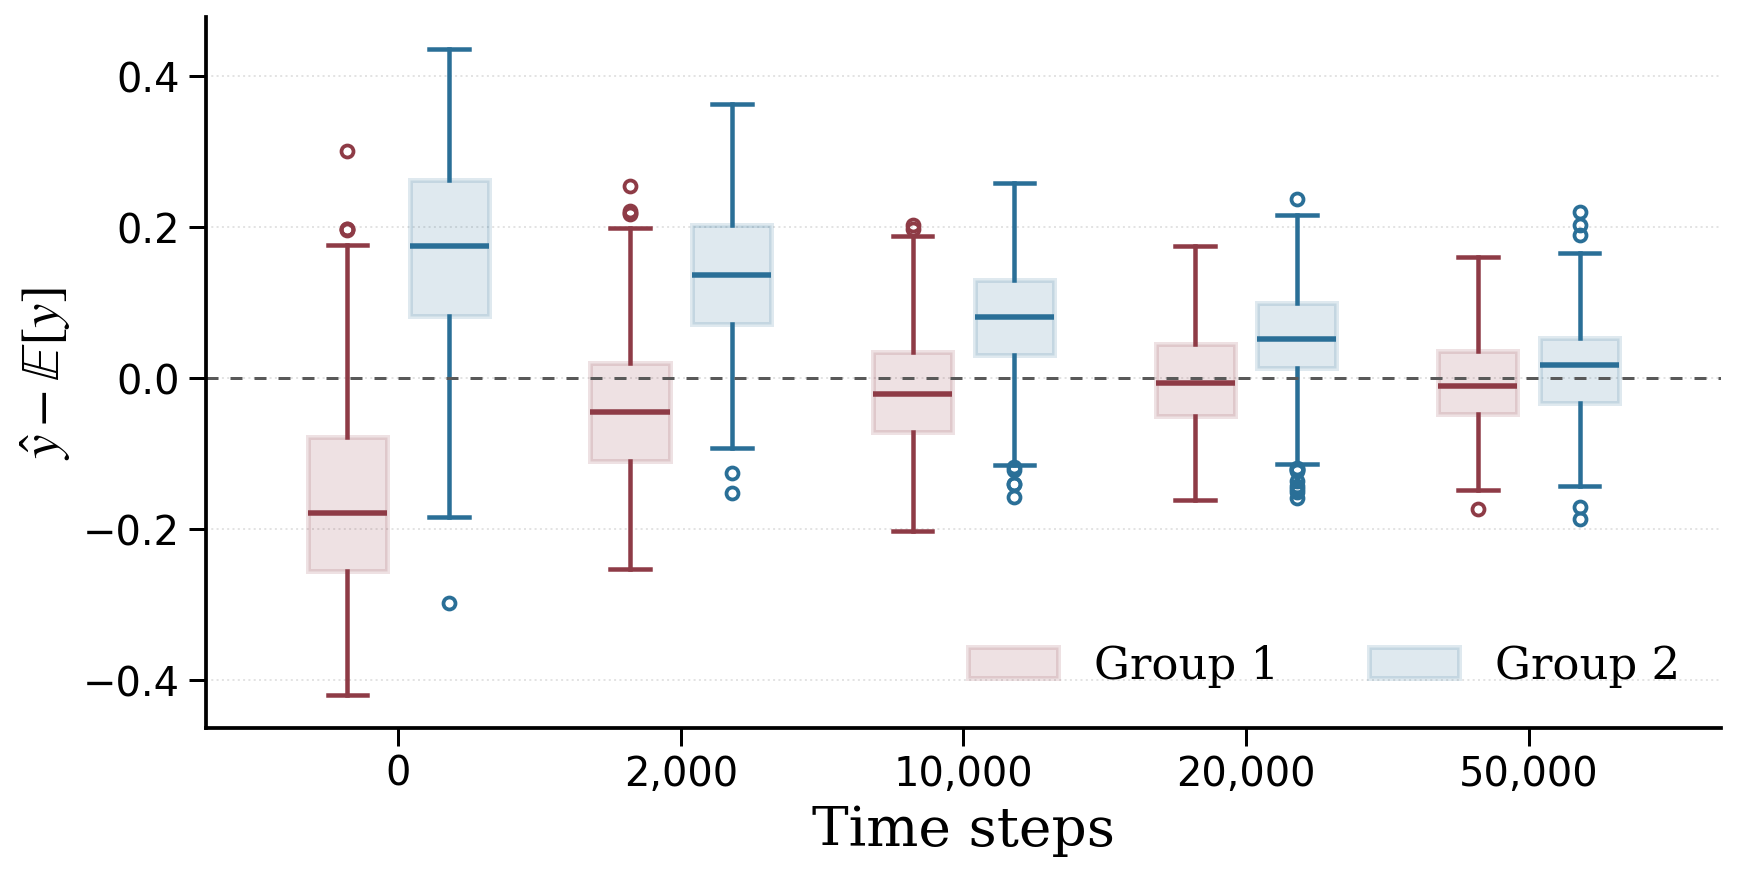

In [25]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

# ML Model Feedback Loop (threshold diferente)

In [26]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [27]:
# Simulación de ML Mode FL
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

error_T_g1 = {}
error_T_g2 = {}

# Variables que creo para análsis
count_d1 = 0
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision (único cambio aquí)
    #y_hat = model.predict([[x]])[0]
    #d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    y_hat = model.predict_proba([[x]])[0,1]
    d = 1 if y_hat > 0.65 else 0

    
    # consecuencias de la decision (solo se añade el par x,y si d=1)
    if d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
    
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
    
    count_d1 += (d == 1)    #test
    count_d0 += (d == 0)
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2

In [28]:
# variables de análsis
print(count_d0, count_d1)

50001 0


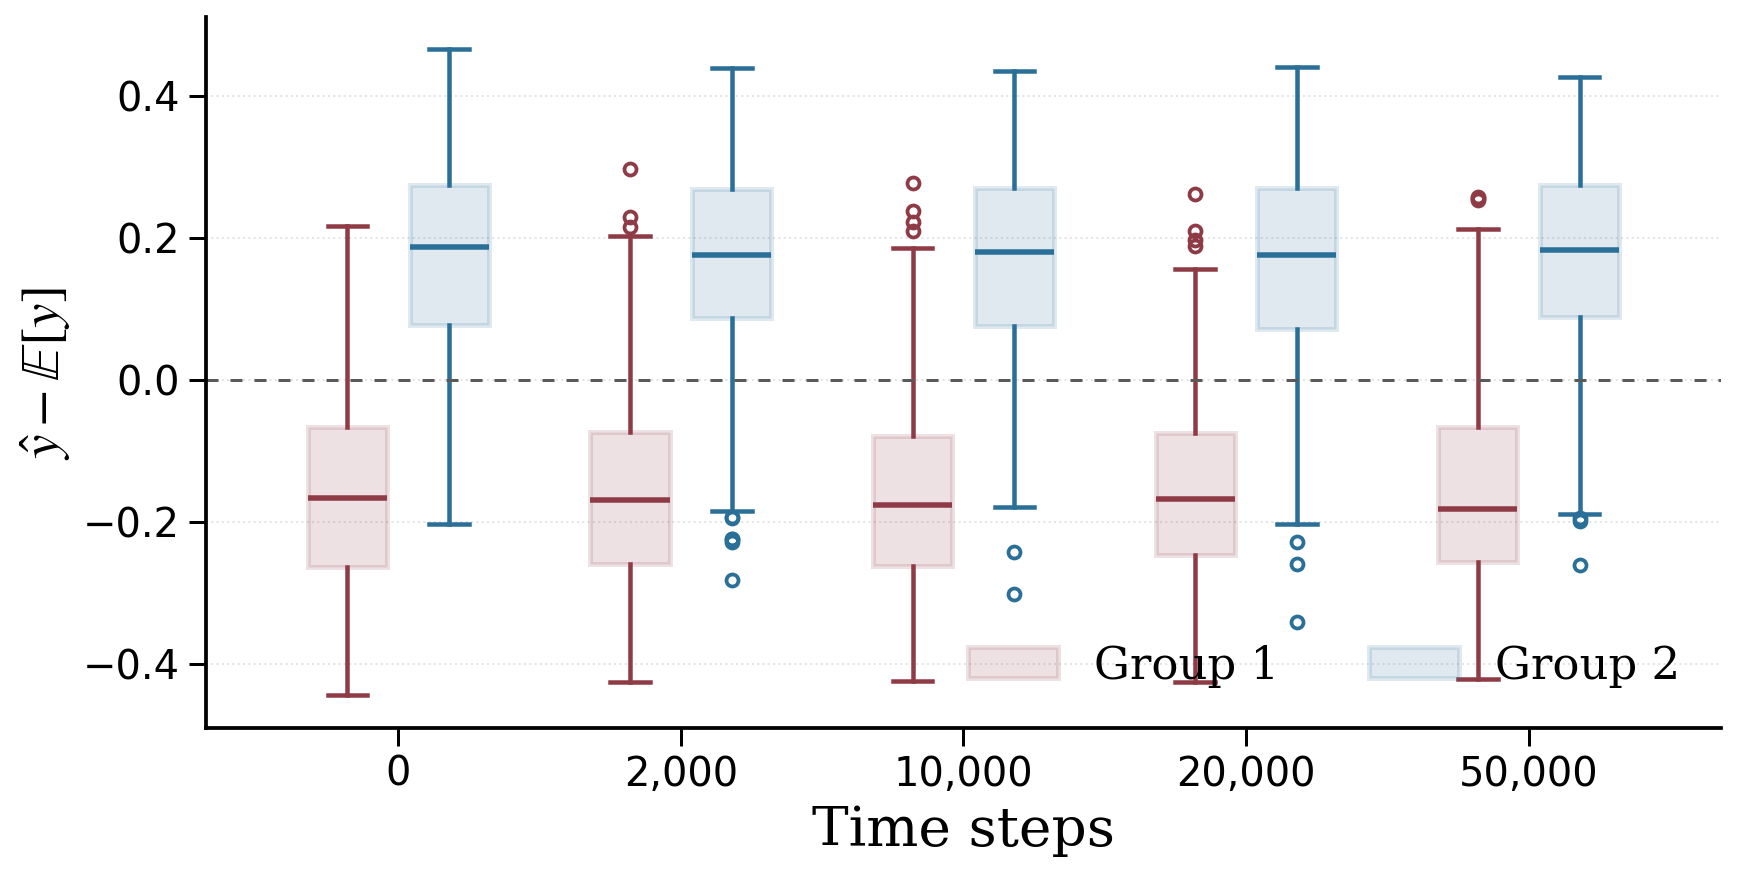

In [29]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

# Coupled Feedback Loop

In [125]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [126]:
# Simulación de ML Model y Sampling FLs acoplados
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Error por iteración
error_T_g1 = {}
error_T_g2 = {}

# Número de usuarios por iteración
g1_T = []
g2_T = []

# inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)


# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}


for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x

    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # consecuencias de la decision (solo se añade el par x,y si d=1, si d=0 usuario se va de la plataforma )
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        else:
            n_g2 -= 1
        new_user = create_user_homophily(user_id, n_g1, n_g2)
        population.append(new_user)
        if new_user.group == 1:
            n_g1 += 1
        else:
            n_g2 += 1
    elif d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
    count_d1 += (d == 1)
    count_d0 += (d == 0)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
        
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [127]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

936 64
703 49298


In [128]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

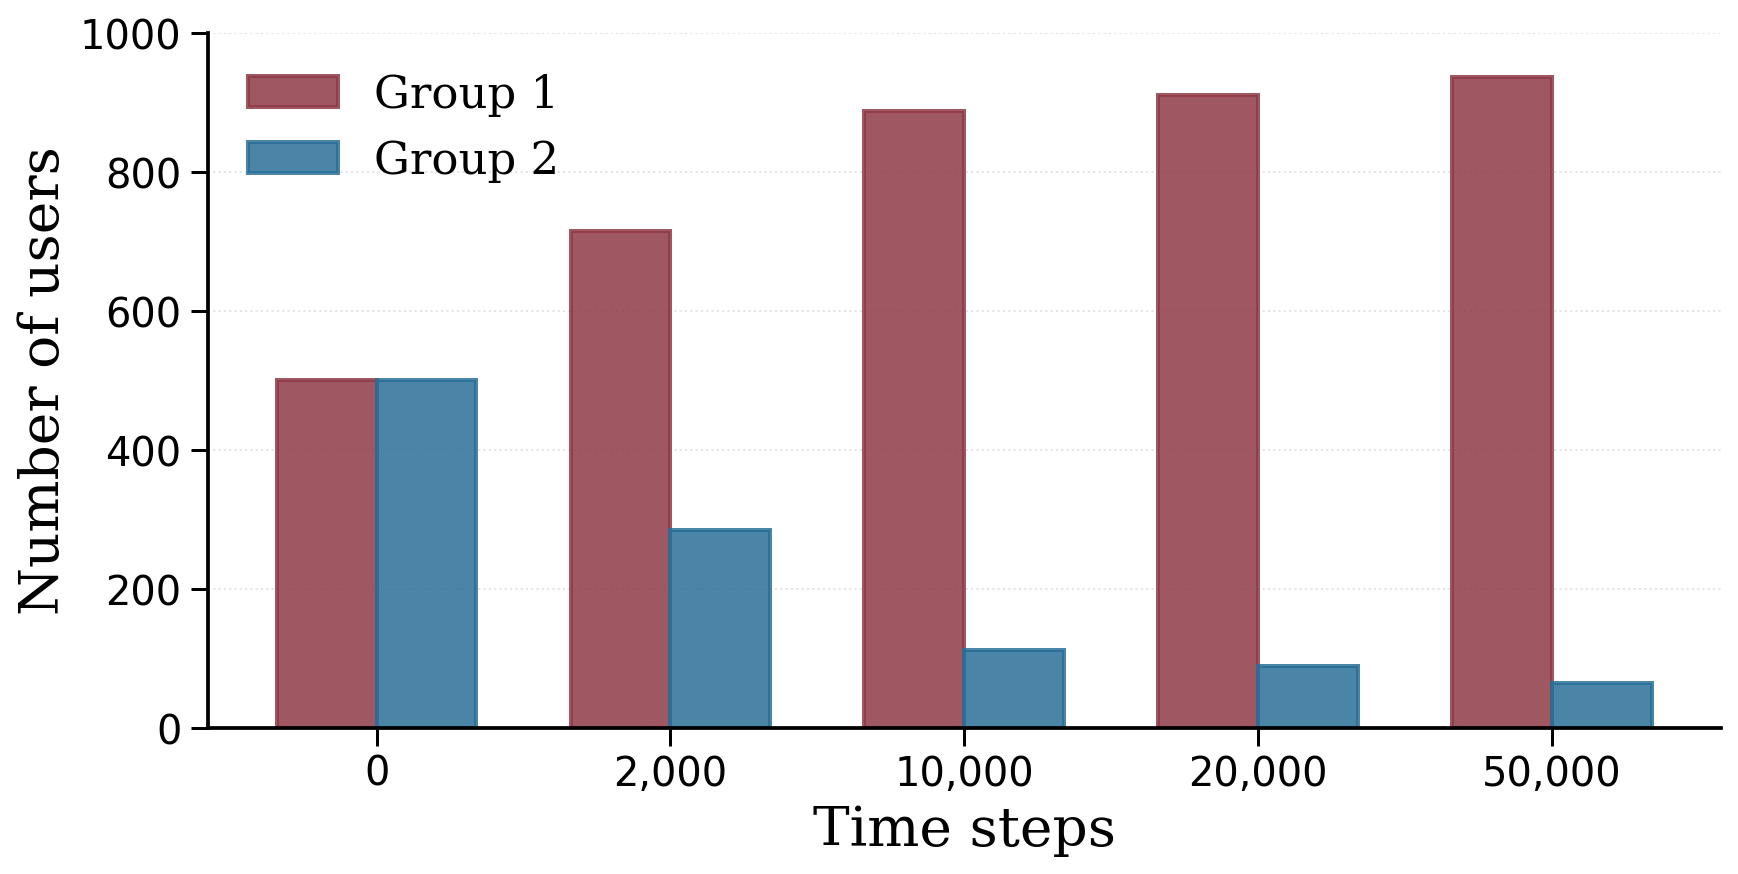

In [129]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

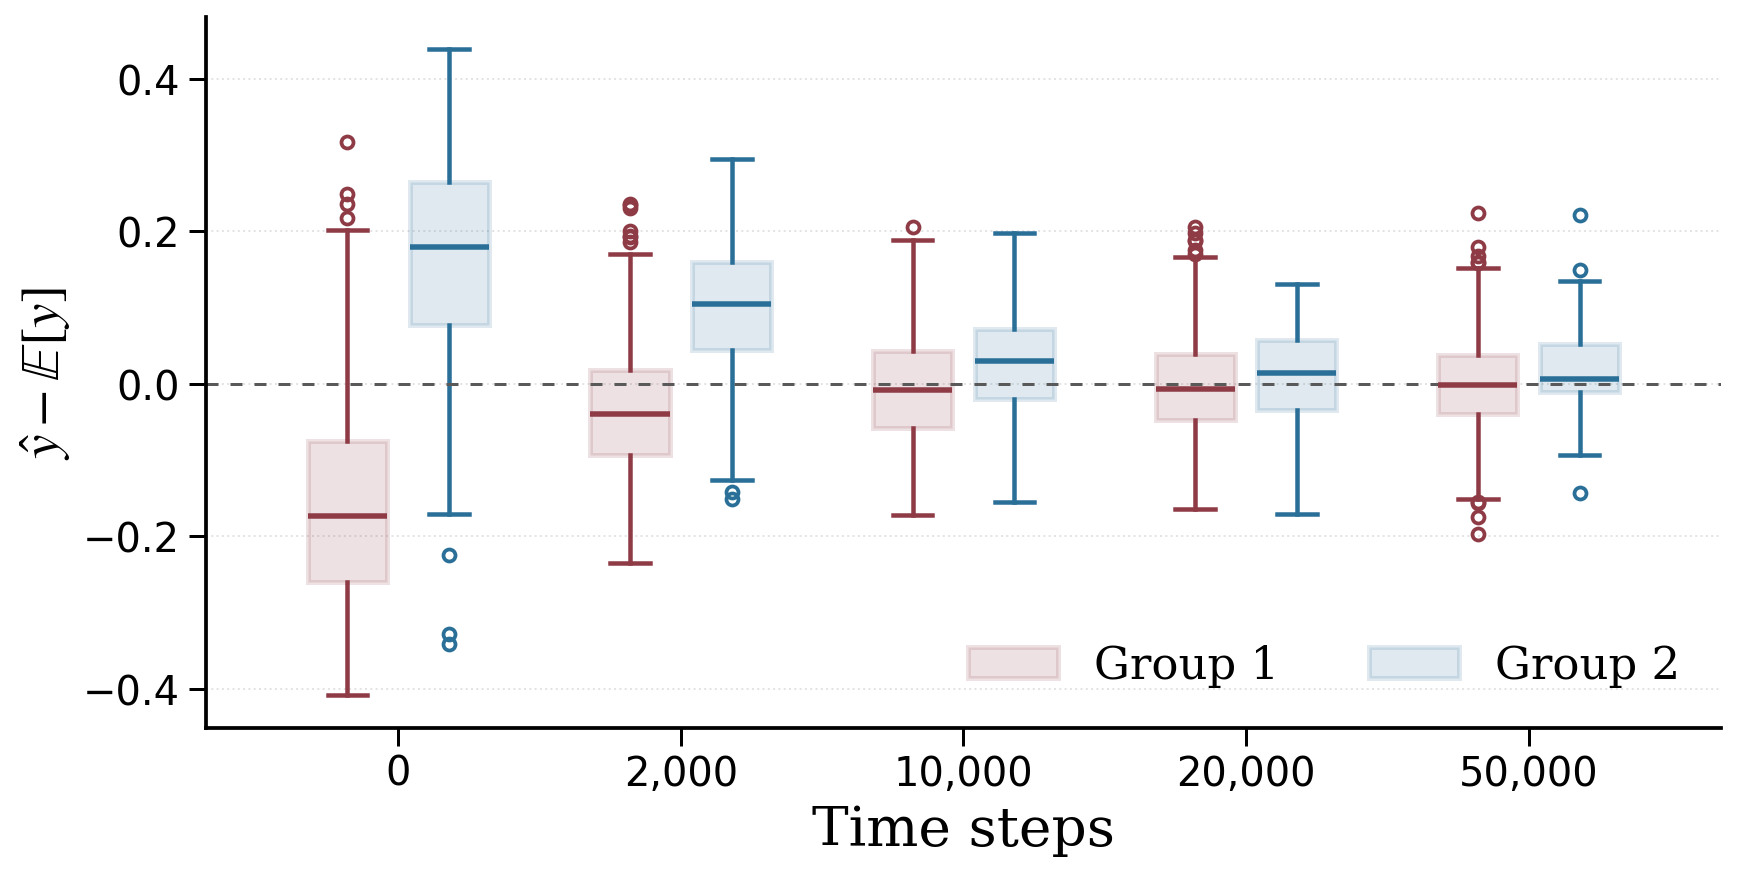

In [130]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

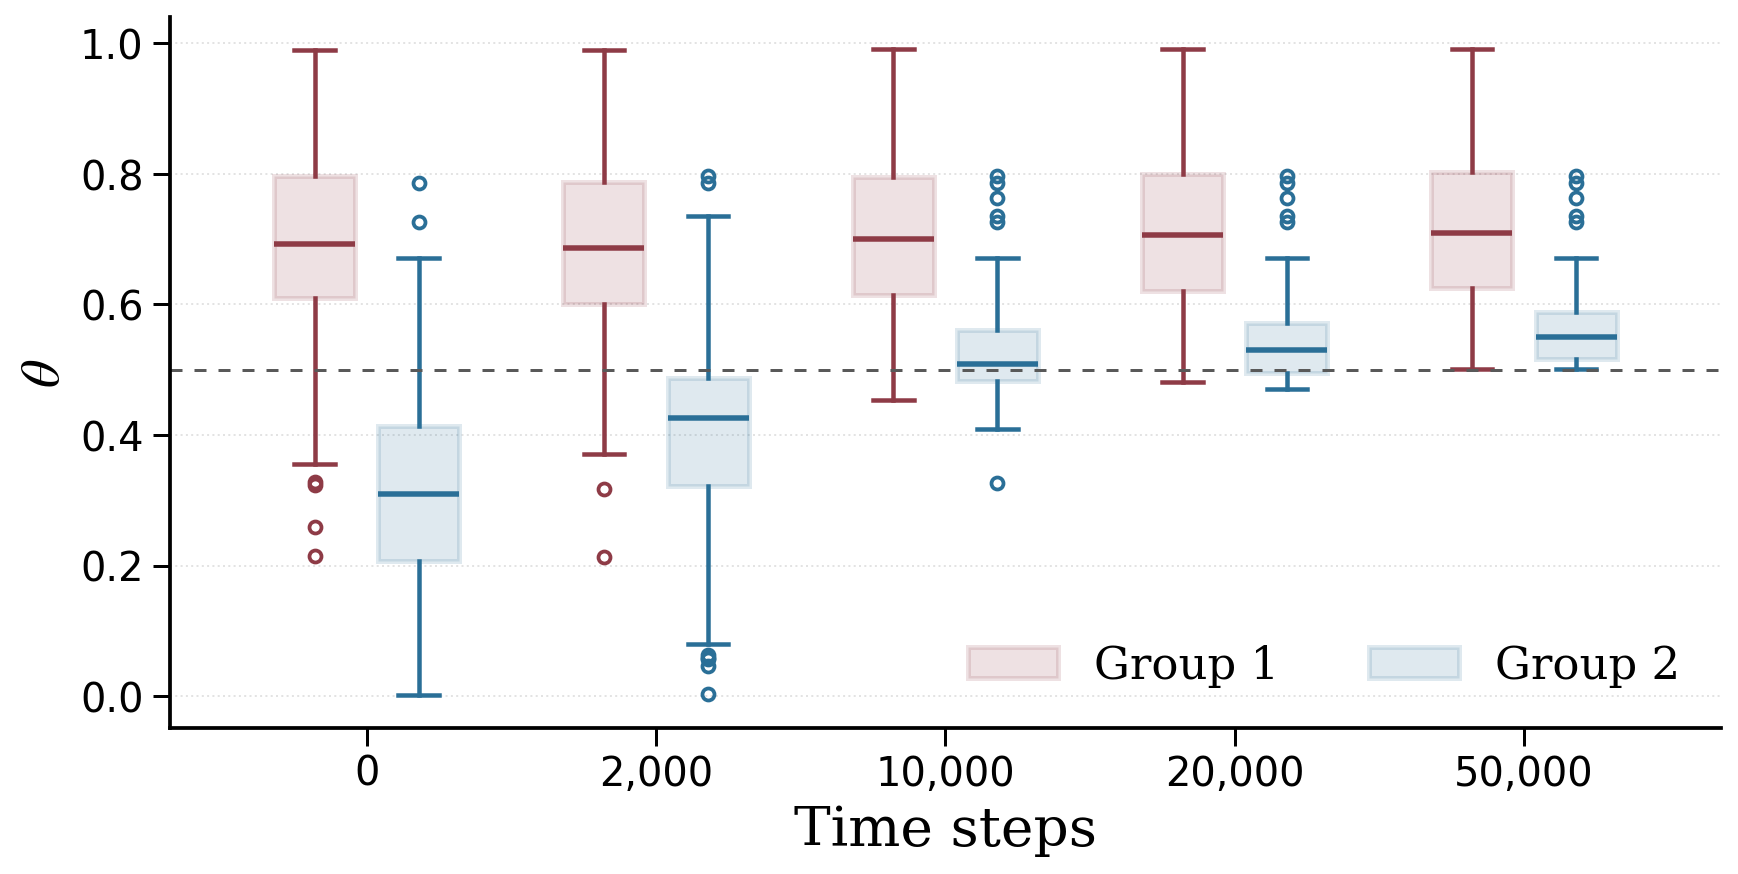

In [131]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta")

# Coupled Feedback Loop (threshold diferente)

In [115]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [116]:
# Simulación de ML Mode y Sampling FLs acoplados
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Error por iteración
error_T_g1 = {}
error_T_g2 = {}

# Número de usuarios por iteración
g1_T = []
g2_T = []

# inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)


# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}


for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x

    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision (único cambio aquí)
    #y_hat = model.predict([[x]])[0]
    #d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    y_hat = model.predict_proba([[x]])[0,1]
    d = 1 if y_hat > 0.65 else 0
    
    # consecuencias de la decision (solo se añade el par x,y si d=1, si d=0 usuario se va de la plataforma )
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        else:
            n_g2 -= 1
        new_user = create_user_homophily(user_id, n_g1, n_g2)
        population.append(new_user)
        if new_user.group == 1:
            n_g1 += 1
        else:
            n_g2 += 1
    elif d == 1:
        X = np.append(X, [[x]], axis=0)
        y = np.append(y, outcome)
        # reentreno el modelo solo si cambio dataset
        model = train_LR(X, y)
    count_d1 += (d == 1)
    count_d0 += (d == 0)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
        
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [118]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

606 394
50001 0


In [119]:
for i in population:
    if model.predict([[i.theta]])[0] == 1:
        pass 
    else:
        print("No todas las decisiones son d=1.")
# si no imprime nada quiere decir que el modelo, para la población última, 
# siempre predice d=1 (no hay sampling)

No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas las decisiones son d=1.
No todas l

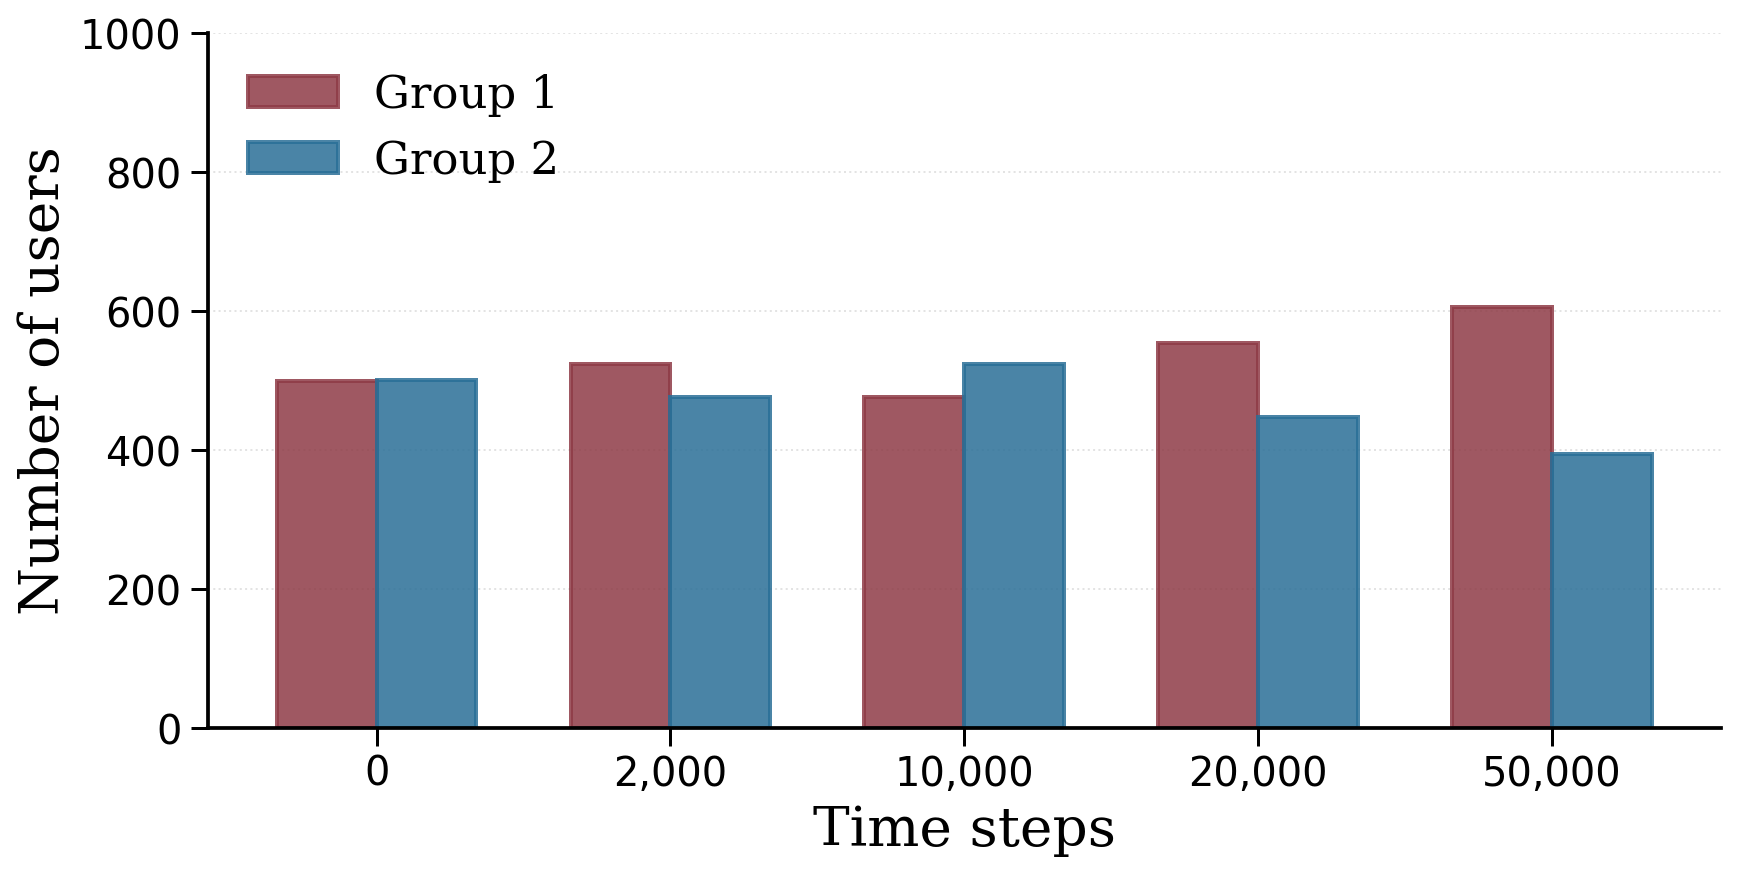

In [120]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

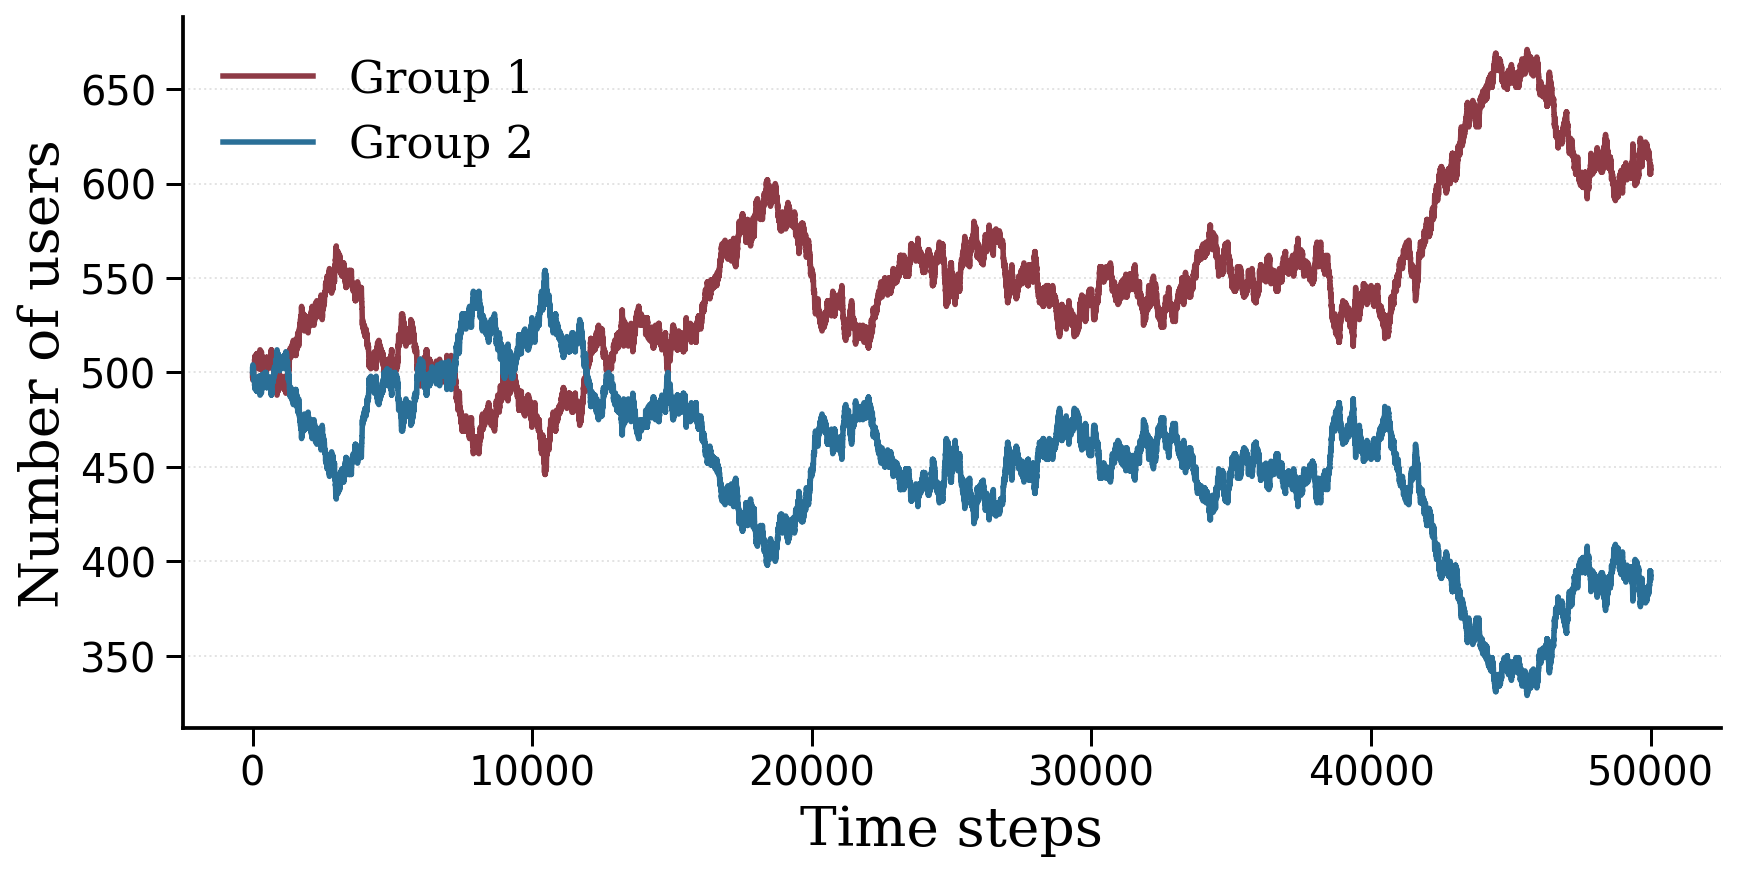

In [121]:
plot_user_T(g1_T, g2_T)

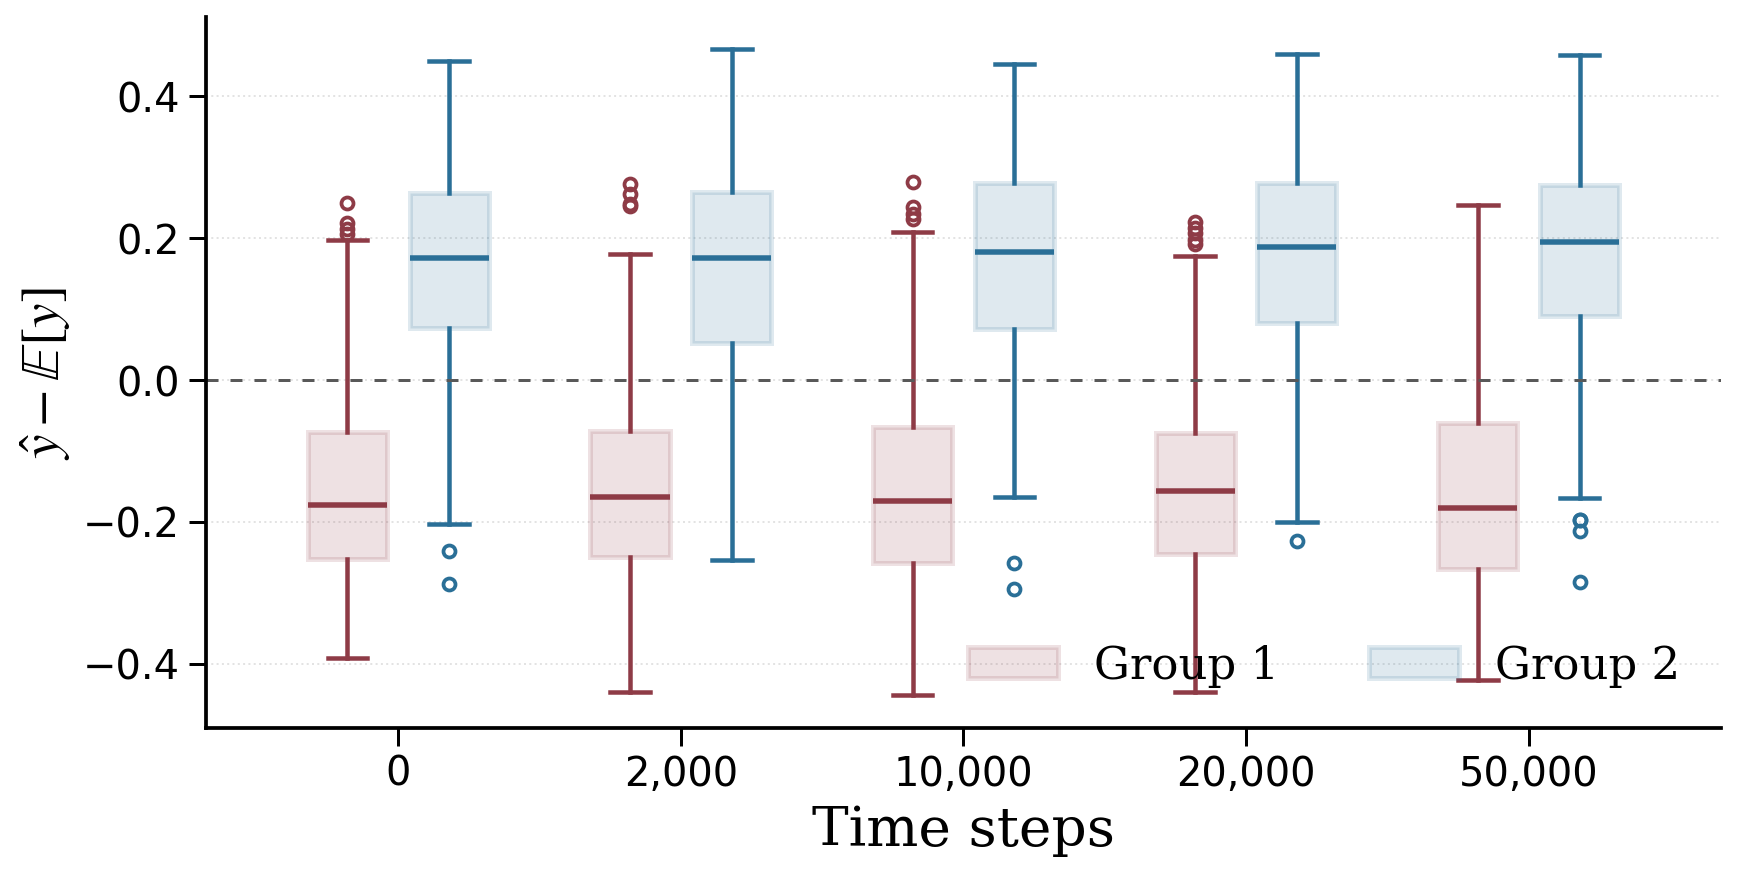

In [122]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

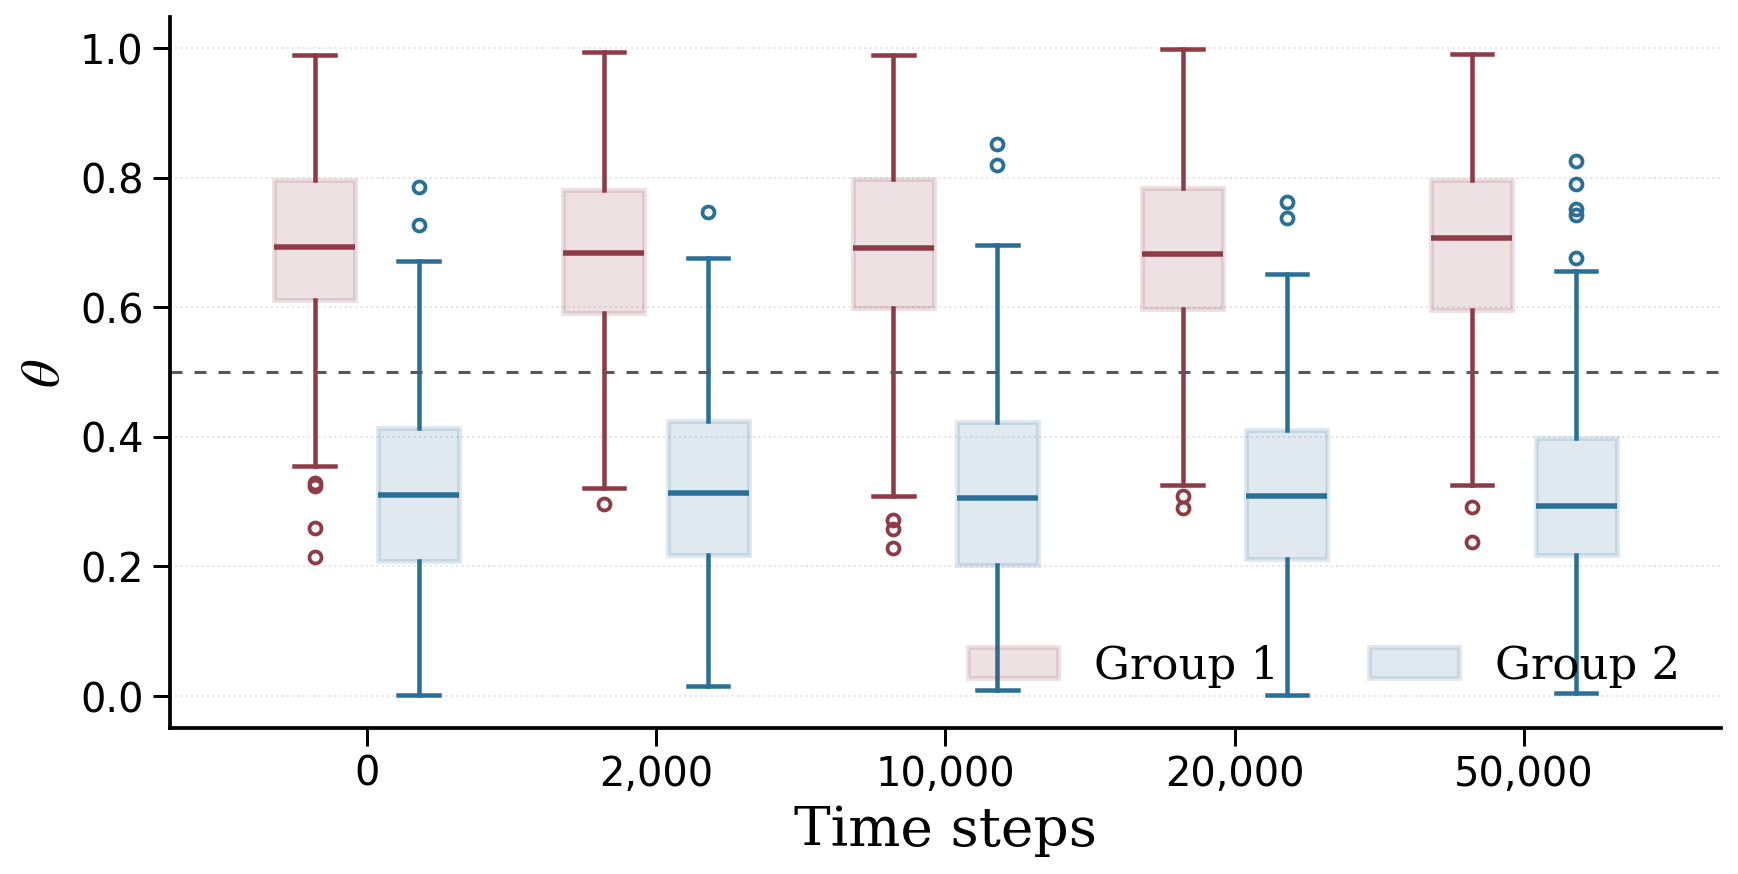

In [123]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta")

-------------------------

A continuación simulo individual aislado, individual-sampling e individual-ml model. Hago todo dos veces: con x fijo (estilo Pagan) y actualizando x con theta (x=theta). Podría argumentar que lo último es una especie de feature fl.

# Individual Feedback Loop (x=theta)

In [45]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [46]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # consecuencias de la decision (cambia interés)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
    else:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    # x = theta
    X = np.append(X, [[user.theta]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # Diccionario donde guardo interés de la población en checkpoint
    # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [47]:
# variables de análsis
print(count_d0, count_d1)

24666 25335


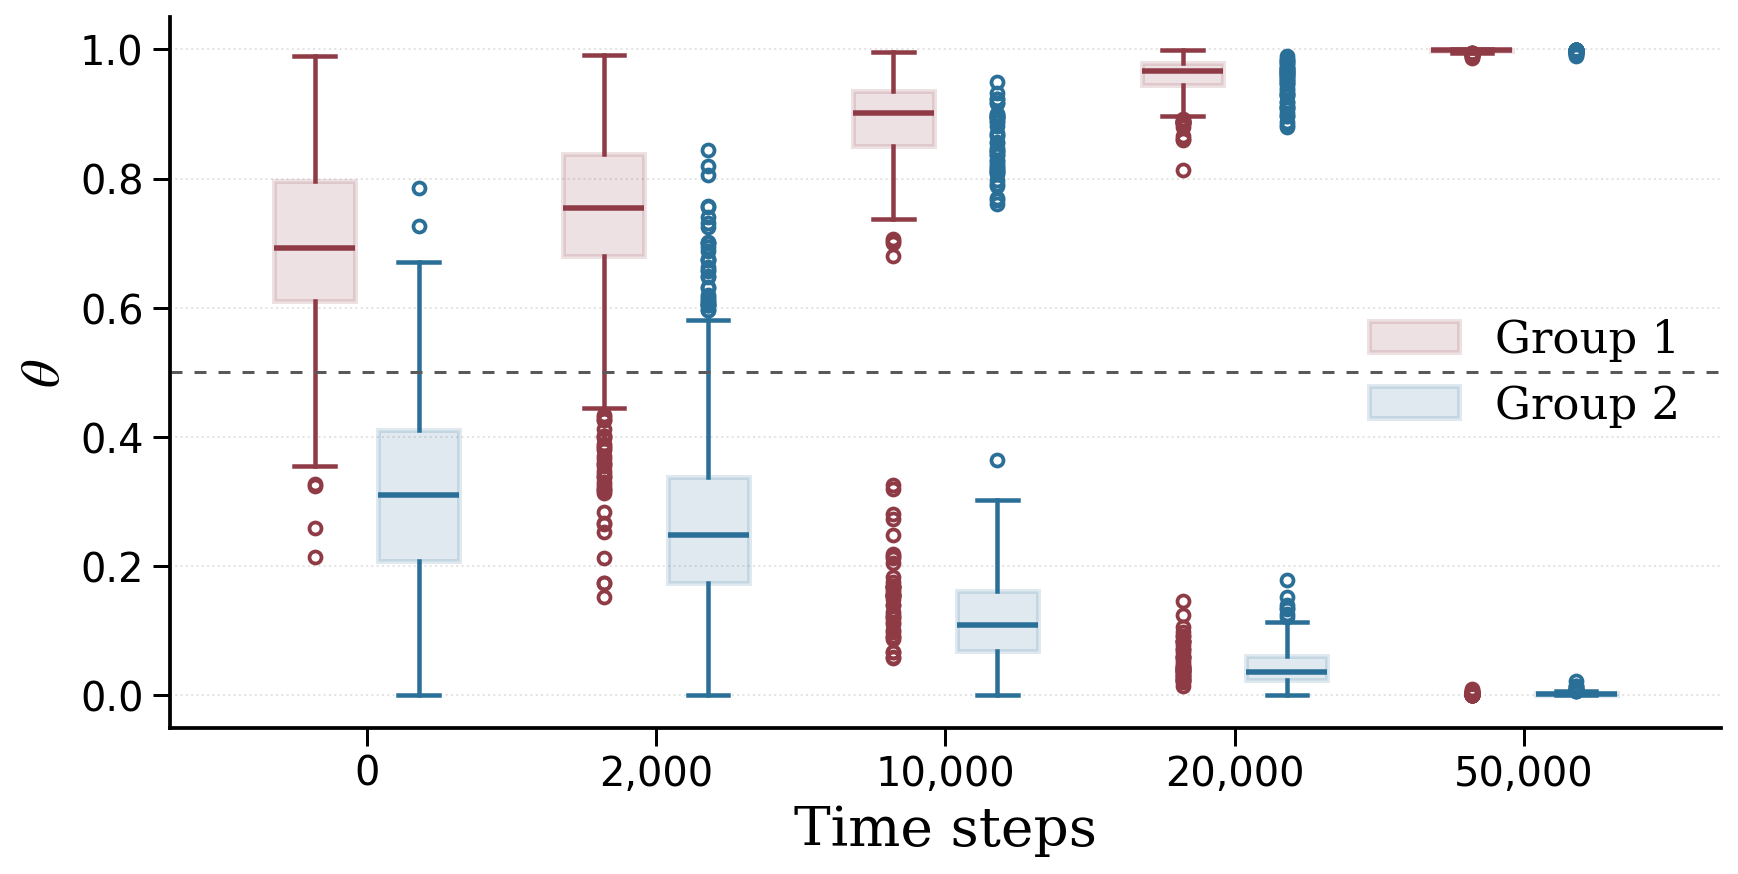

In [48]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "center right", 1)

# Individual Feedback Loop (x fijo)

In [49]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [50]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # consecuencias de la decision (cambia interés)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
    else:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    # añadimos par x,y donde x es fijo
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [51]:
# variables de análsis
print(count_d0, count_d1)

24904 25097


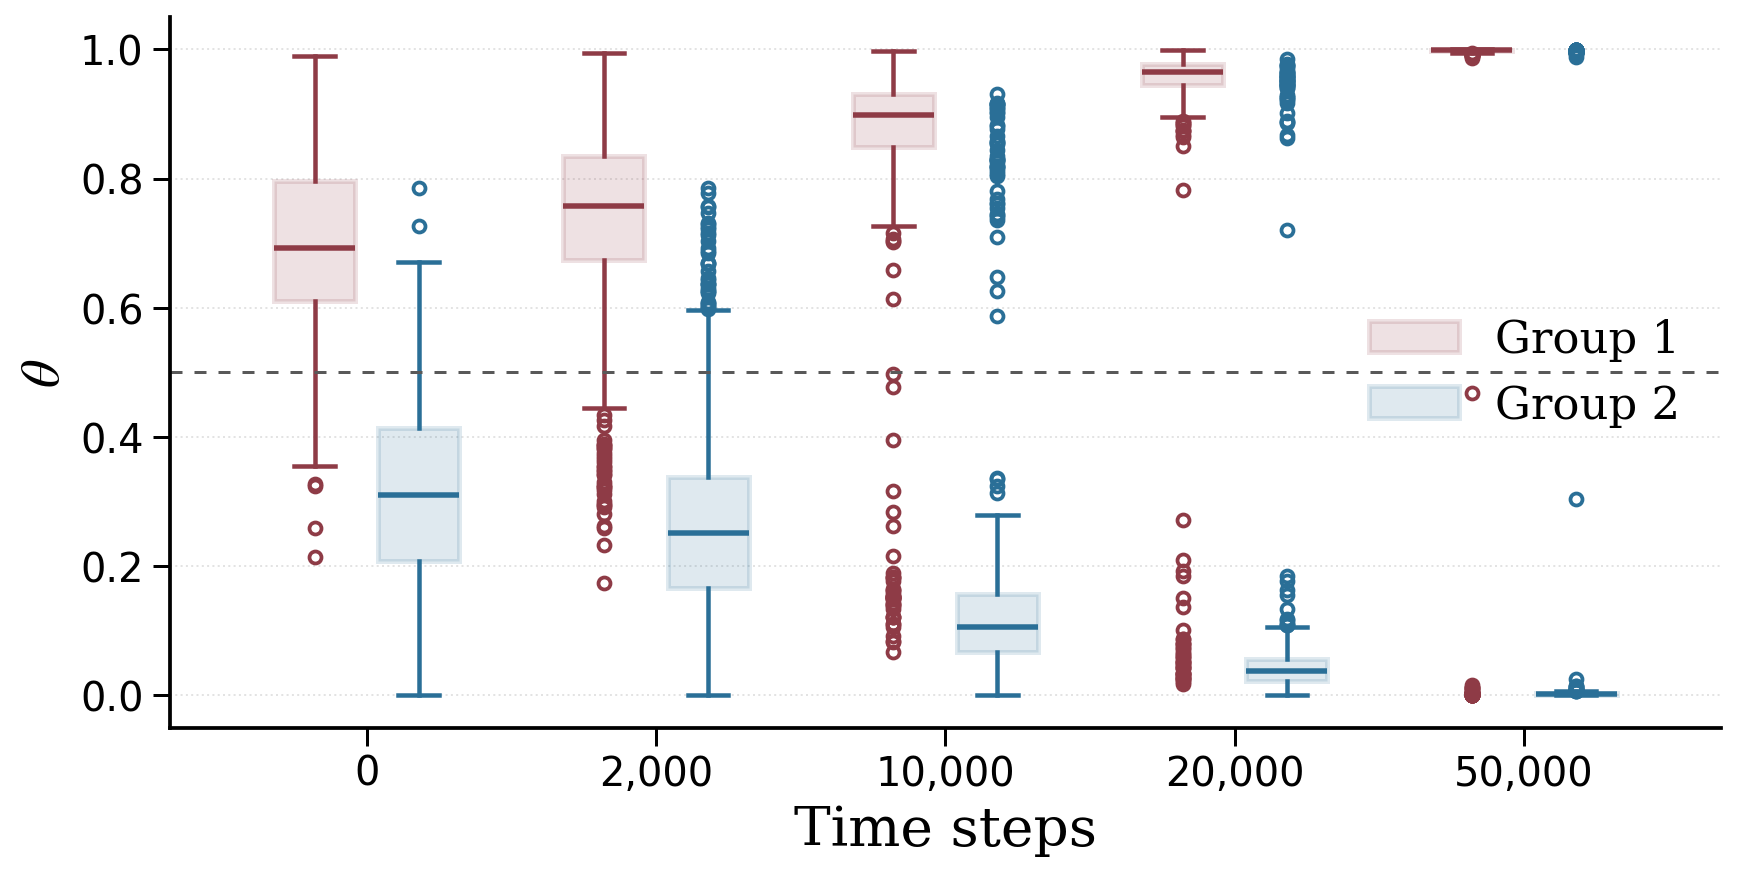

In [52]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "center right", 1)

# Coupled Sampling-Individual (x=theta)

La decision d afecta a theta y quién entra y sale de la plataforma. Se pueden seguir dos estrategias aquí:  
     - si d=1: usuario permanece en la plataforma y theta sube.  
     - si d=0: usuario abandona la plataforma y theta baja.  
Segunda estrategia:  
     - si d=1: usuario permanece en la plataforma y theta sube.  
     - si d=0: usuario tiene un "vida" que cuando llegue a 0 abandona la plataforma, mientras tenga vida permanece, baja theta si d=0.  
En realidad da un poco igual cuál elegimos, la cuestión es comparar el acoplado con sus respectivos aislados. Vamos a ver primero la primera estrategia.

### Estrategia 1 (agresiva)

In [53]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [54]:
# prueba: individual + sampling
# Simulación de sampling FL

T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []

# Inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta

    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
            
    # consecuencias de la decision (quitar usuario, meter uno nuevo)
    if d == 0:
        population.remove(user)
        if group == 1:
            n_g1 -= 1
        else:
            n_g2 -= 1
        new_user = create_user_homophily(user_id, n_g1, n_g2)
        population.append(new_user)
        if new_user.group == 1:
            n_g1 += 1
        else:
            n_g2 += 1
    elif d==1:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
            
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
        
    # añadir x,y al dataset (x=theta)
    X = np.append(X, [[user.theta]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [55]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

938 62
766 49235


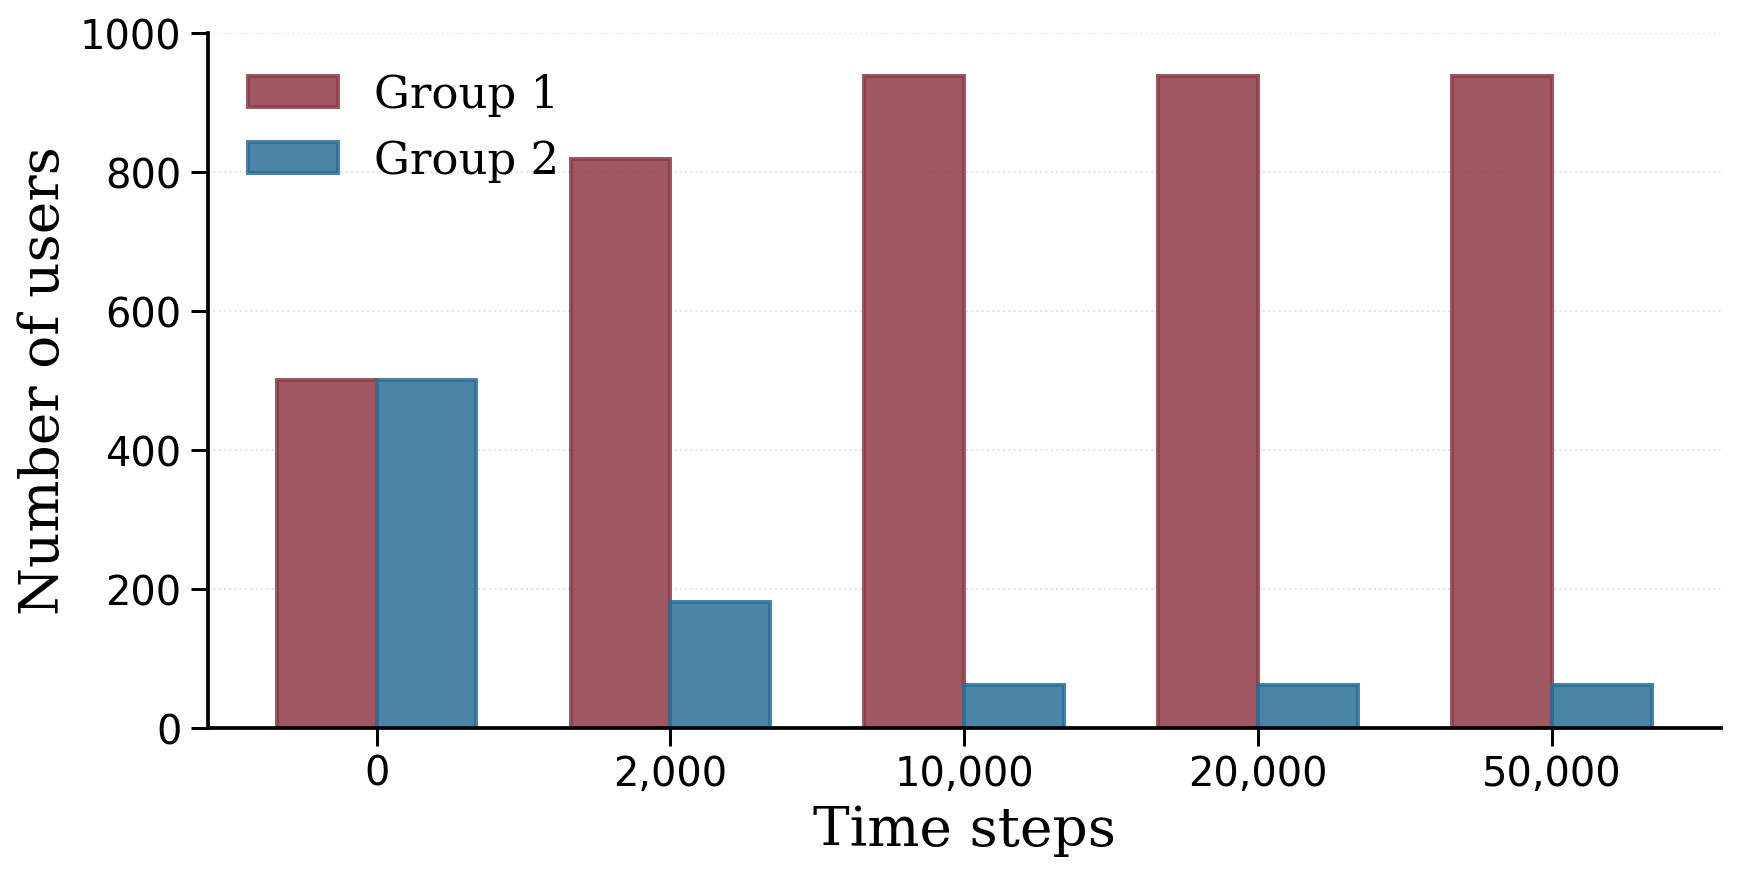

In [56]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

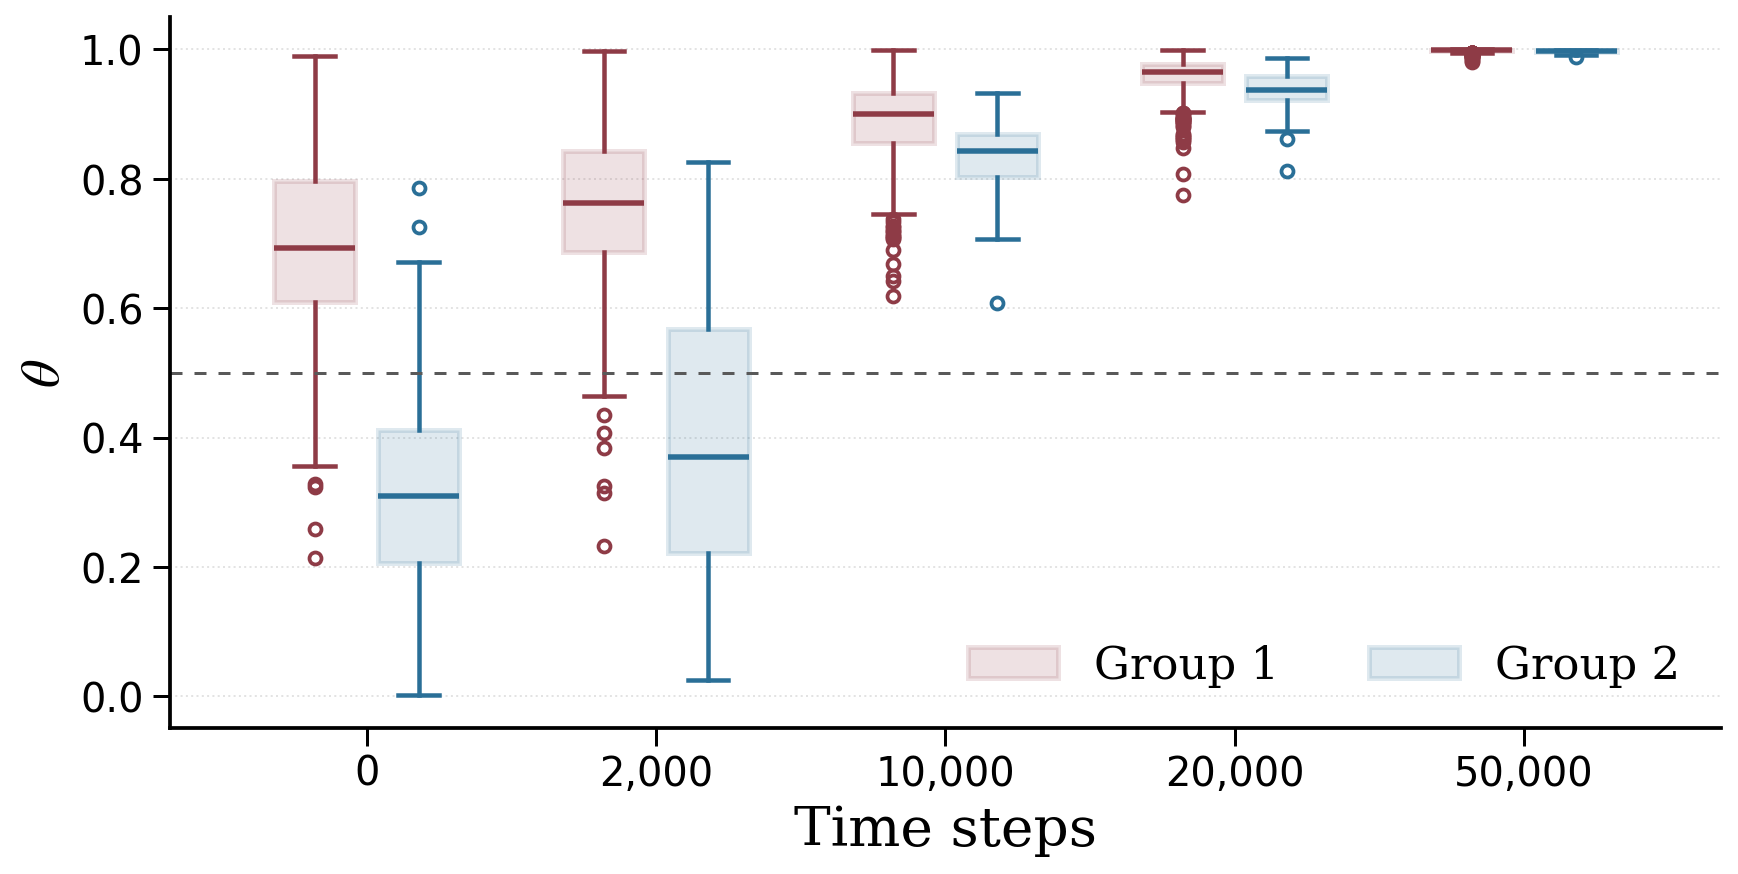

In [57]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta")

### Estrategia 2

In [58]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [59]:
# prueba: individual + sampling
# Simulación de sampling FL

T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []

# Inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta

    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
            
    # consecuencias de la decision (quitar usuario/bajar interes y meter uno nuevo; 
    # subir interes)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
        user.cont_d0 +=1
        if user.cont_d0 >= 3:
            population.remove(user)
            if group == 1:
                n_g1 -= 1
            else:
                n_g2 -= 1
            new_user = create_user_homophily(user_id, n_g1, n_g2)
            population.append(new_user)
            if new_user.group == 1:
                n_g1 += 1
            else:
                n_g2 += 1
    elif d==1:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
            
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
        
    # añadir x,y al dataset   (x=theta)
    X = np.append(X, [[user.theta]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [60]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

939 61
2202 47799


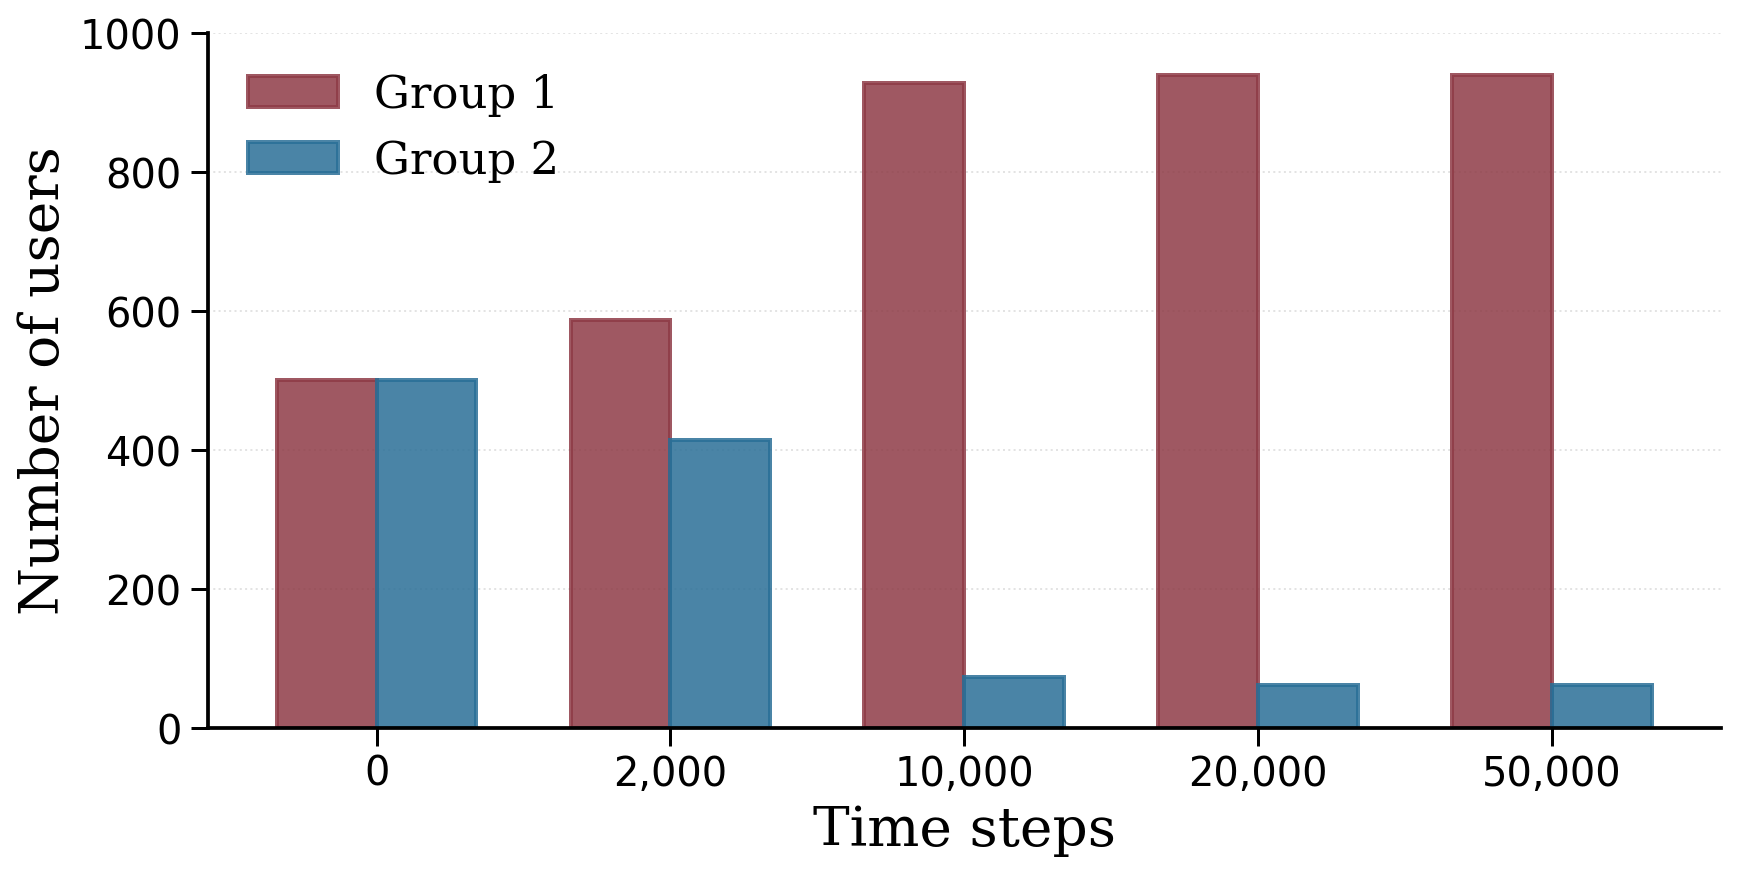

In [61]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

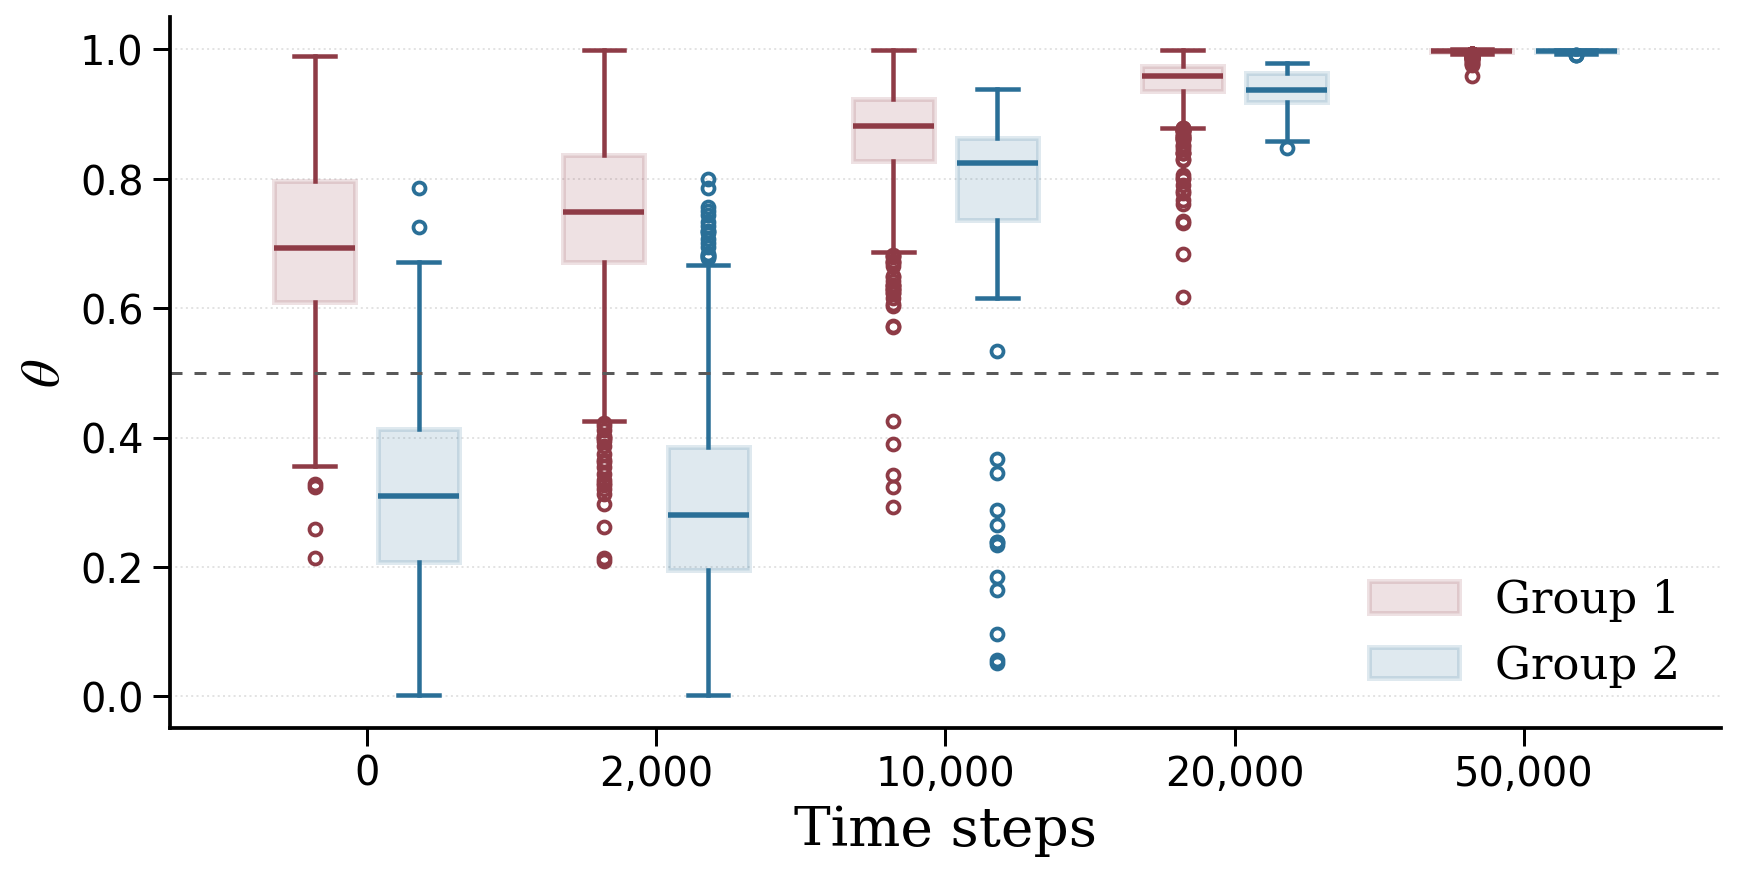

In [62]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "lower right", 1)

# Coupled Sampling-Individual (x fijo)

Sigo solo estrategia 2

In [63]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [64]:
# prueba: individual + sampling
# Simulación de sampling FL

T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Número de usuarios por iteración
g1_T = []
g2_T = []

# Inicializamos contaderos de usuarios
n_g1 = sum(u.group == 1 for u in population)
n_g2 = sum(u.group == 2 for u in population)

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}

for i in range(0, T+1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x

    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
            
    # consecuencias de la decision (quitar usuario/bajar interes y meter uno nuevo; 
    # subir interes)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
        user.cont_d0 +=1
        if user.cont_d0 >= 3:
            population.remove(user)
            if group == 1:
                n_g1 -= 1
            else:
                n_g2 -= 1
            new_user = create_user_homophily(user_id, n_g1, n_g2)
            population.append(new_user)
            if new_user.group == 1:
                n_g1 += 1
            else:
                n_g2 += 1
    elif d==1:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
            
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
        
    # añadir x,y al dataset   (x fijo)
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    g1_T.append(n_g1)
    g2_T.append(n_g2)
    
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [65]:
# variables de análsis
print(n_g1, n_g2)
print(count_d0, count_d1)

931 69
2305 47696


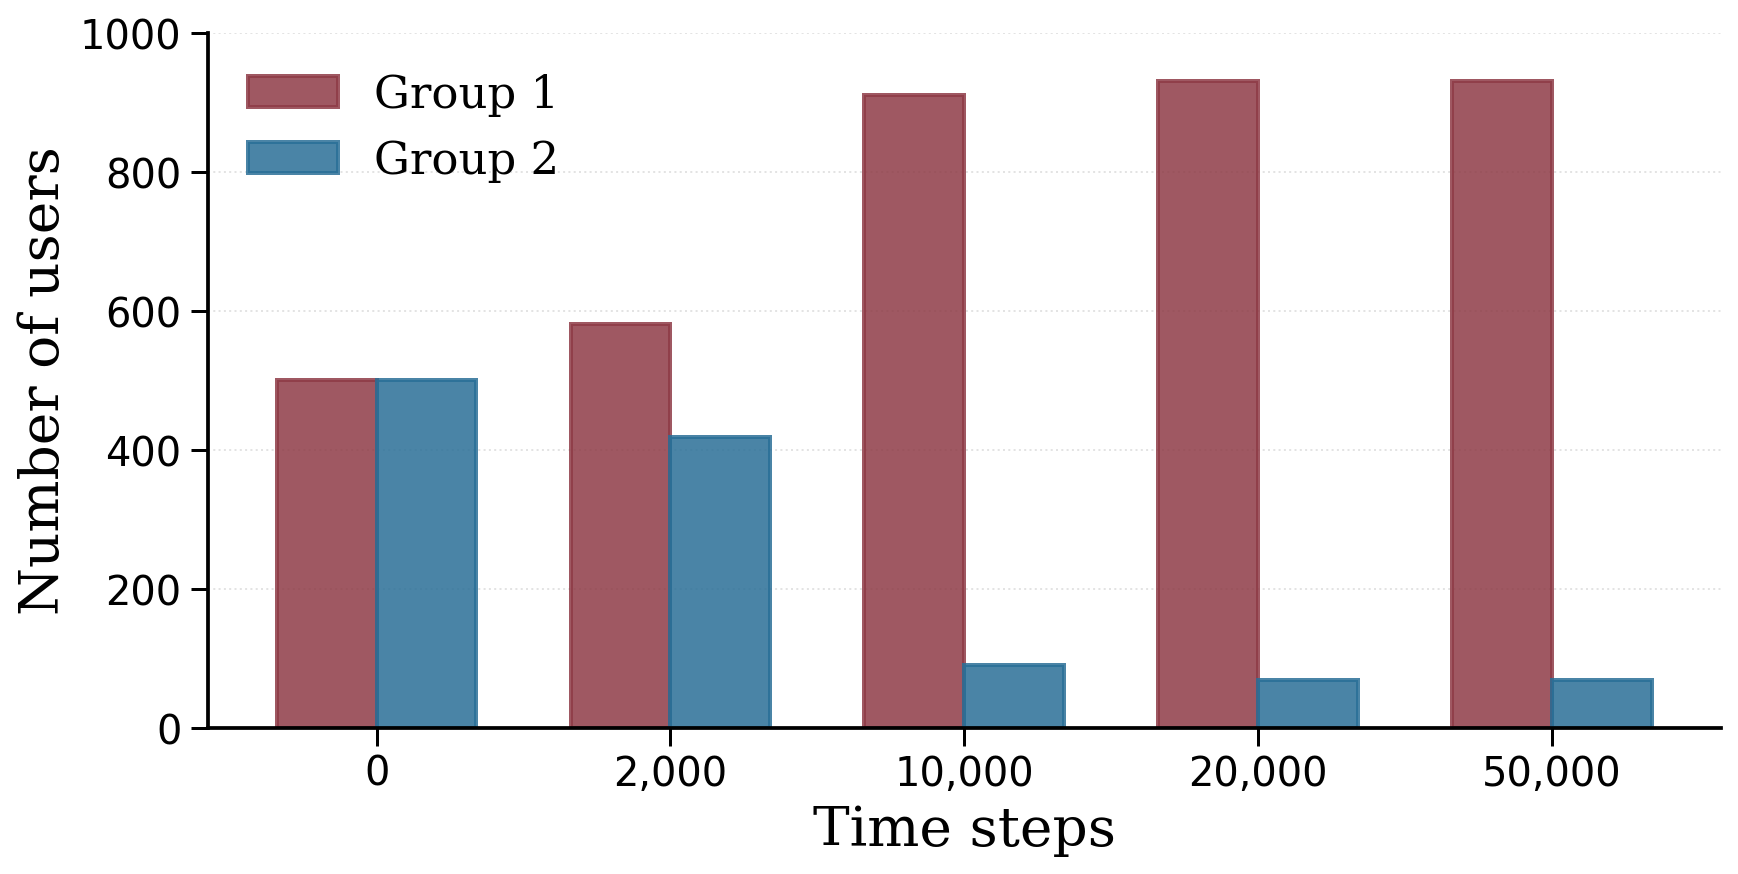

In [66]:
plot_user_checkpoints(g1_T, g2_T, checkpoints)

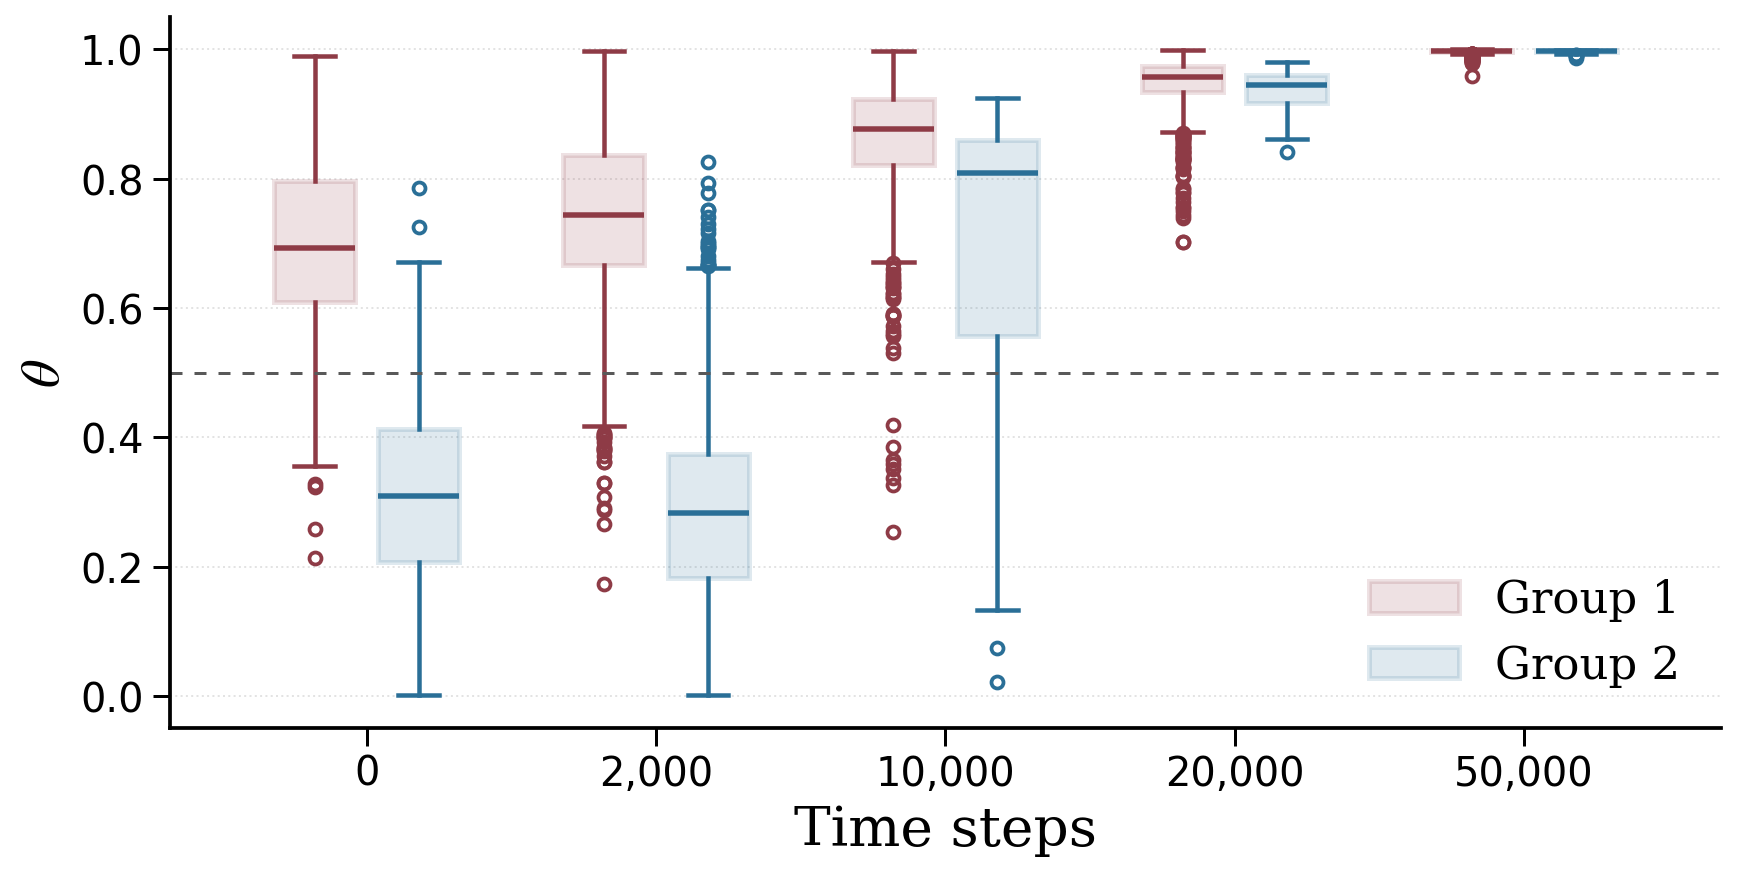

In [67]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "lower right", 1)

# Coupled Individual-ML Model (x=theta)

In [68]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [69]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Error por iteración
error_T_g1 = {}
error_T_g2 = {}

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}


for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta  # !!!!!!!!
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # consecuencias de la decision (cambia interés y añado x,y y reentreno solo si d=1)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
    else:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
        X = np.append(X, [[user.theta]], axis=0) # !!!!!!!!!
        y = np.append(y, outcome)
        model = train_LR(X, y)
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
     # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
    
    # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [70]:
# variables de análsis
print(count_d0, count_d1)

17497 32504


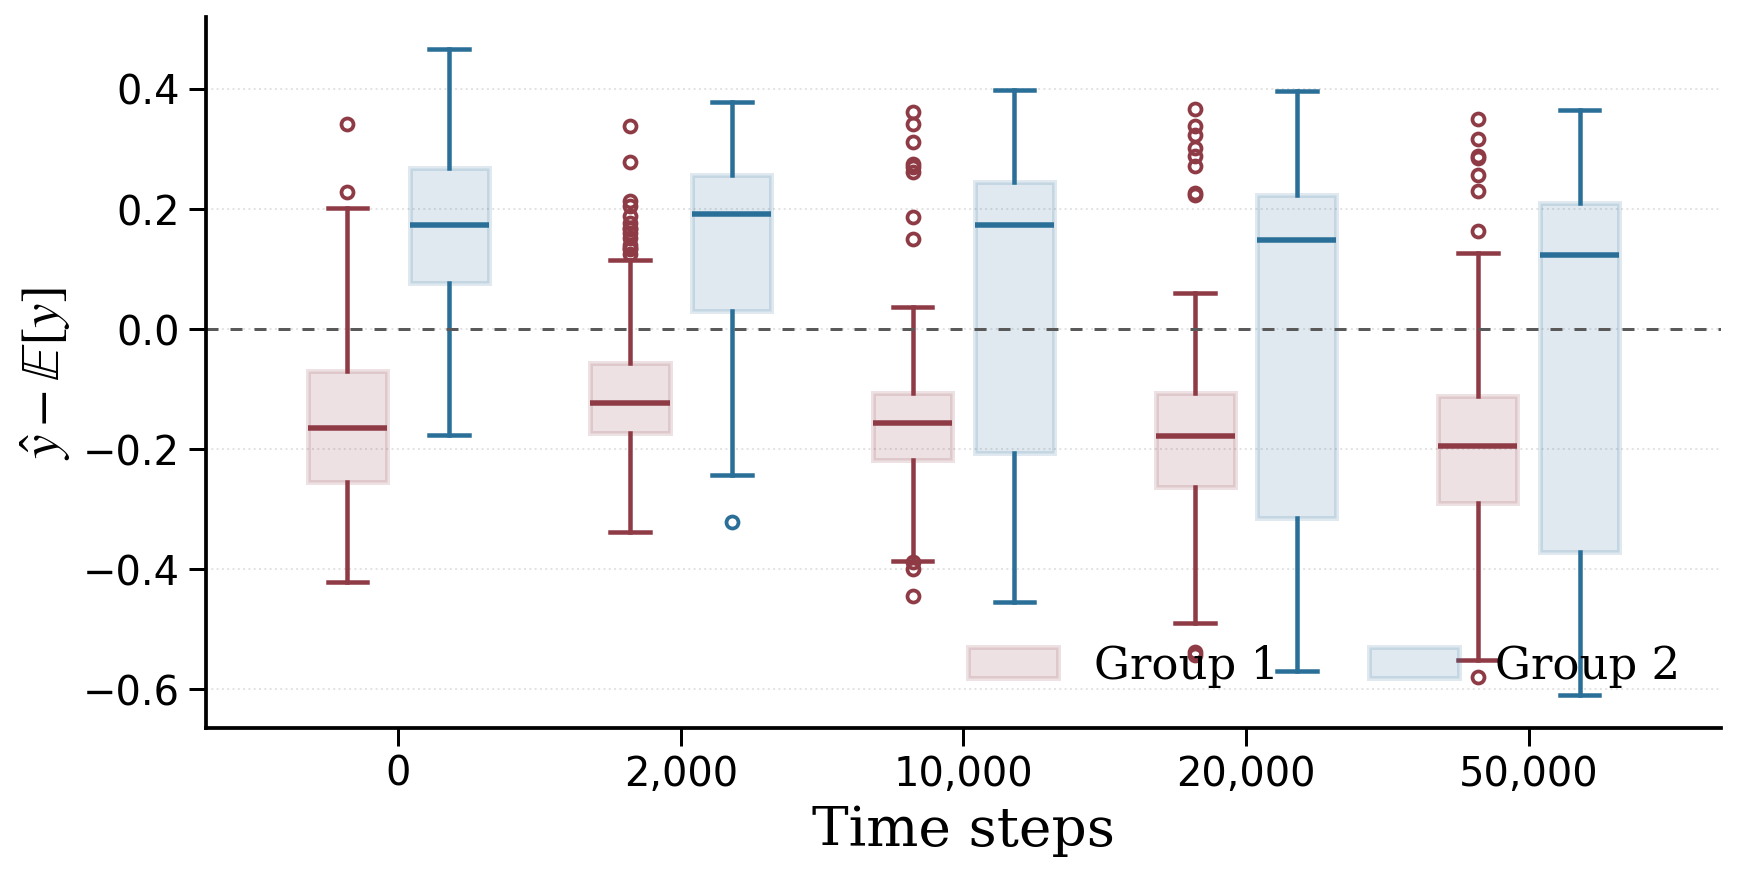

In [71]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

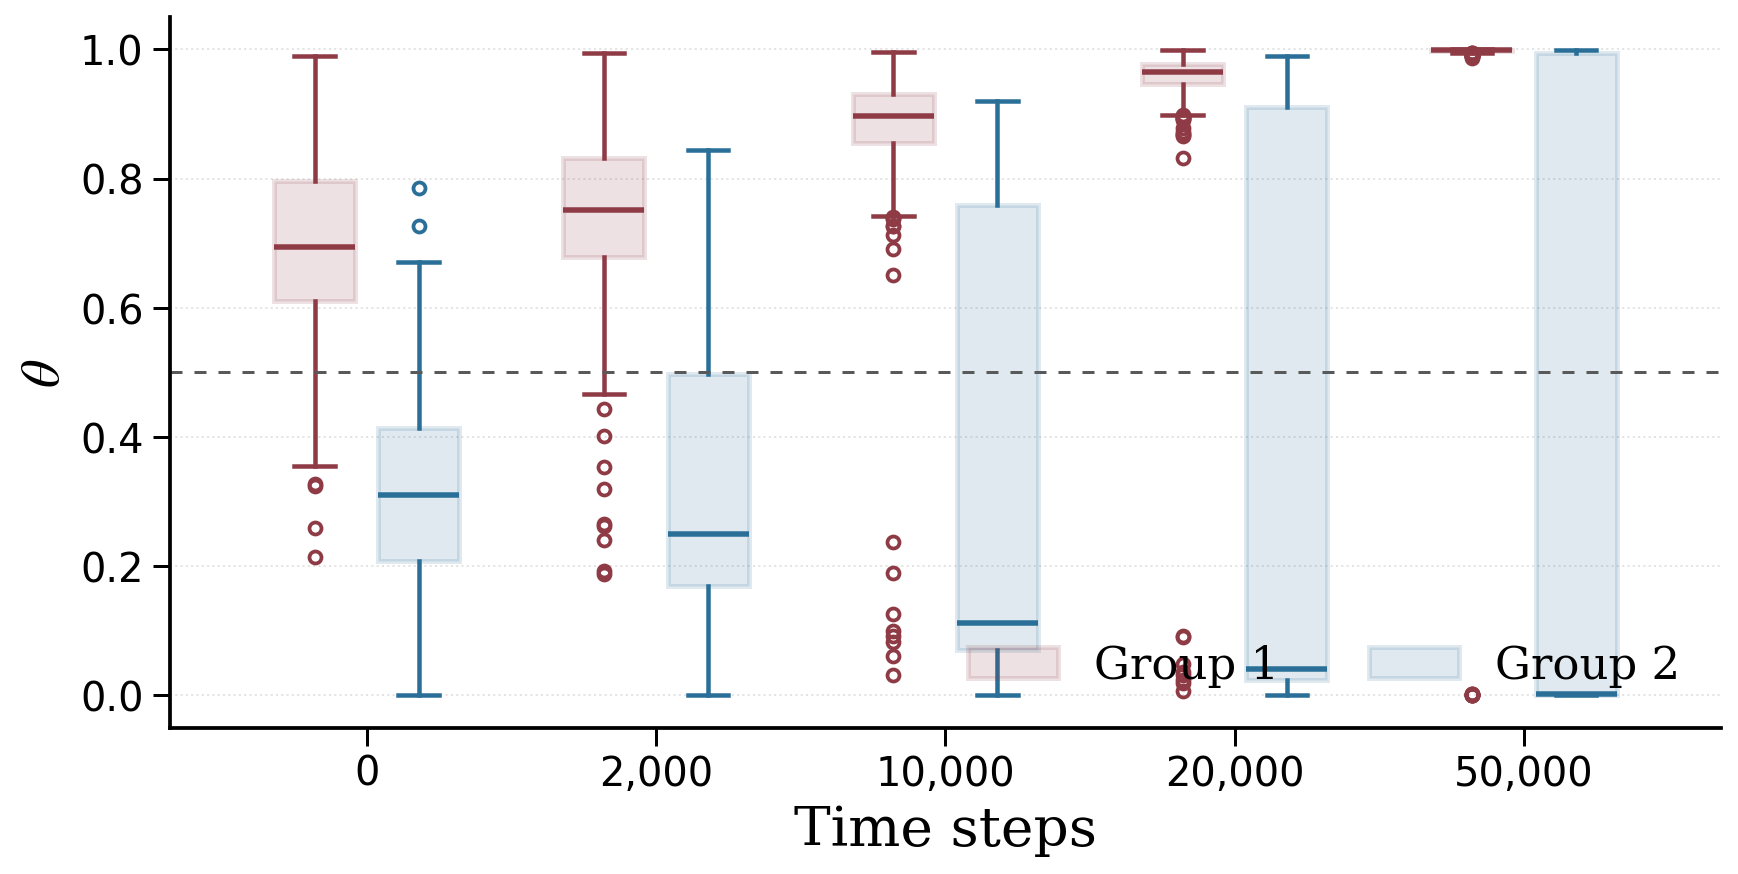

In [72]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta")

# Coupled Individual-ML Model (x= fijo)

In [73]:
X = copy.deepcopy(X_noisy_start)
y = copy.deepcopy(y_noisy_start)
model = copy.deepcopy(initial_noisy_model)
population = copy.deepcopy(initial_population)

In [74]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

# Error por iteración
error_T_g1 = {}
error_T_g2 = {}

# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

    # Diccionario donde guardo interés de la población en checkpoint
theta_T_g1 = {}
theta_T_g2 = {}


for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x  
    
    # outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # consecuencias de la decision (cambia interés y añado x,y y reentreno solo si d=1)
    if d == 0:
        user.theta = min(1, max(0, 0.9*theta))
    else:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
        X = np.append(X, [[x]], axis=0) # cambiar x por theta
        y = np.append(y, outcome)
        model = train_LR(X, y)
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
     # guardo error de predicción (y.pred_proba - E(y)) en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
    
    # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [75]:
# variables de análsis
print(count_d0, count_d1)

6145 43856


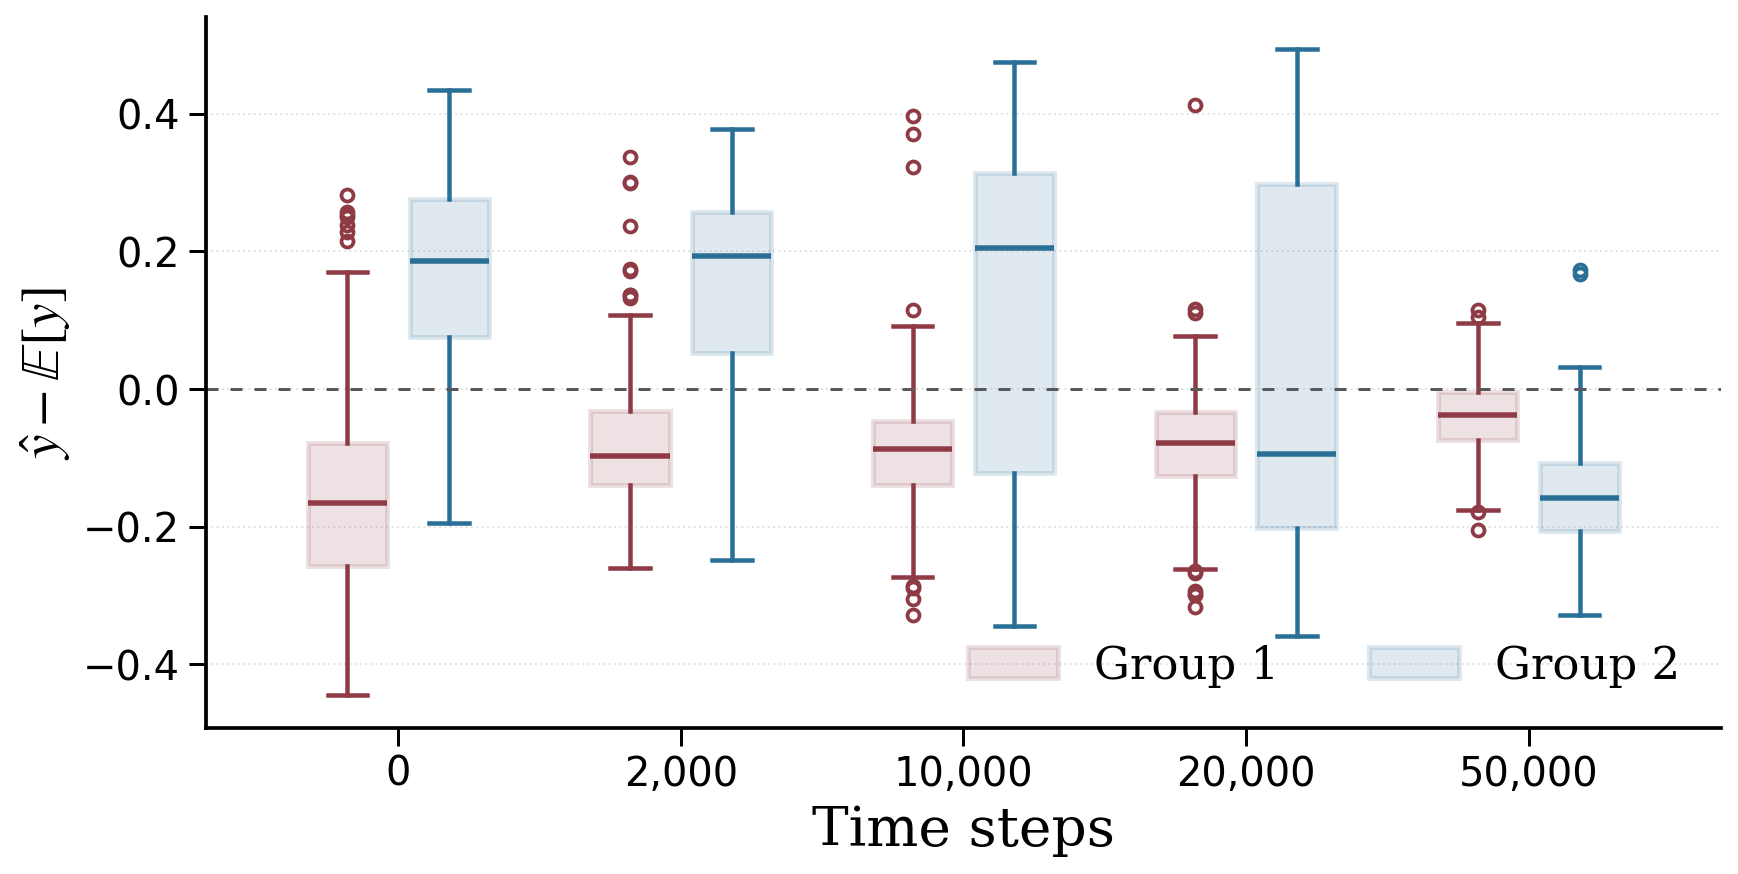

In [76]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error")

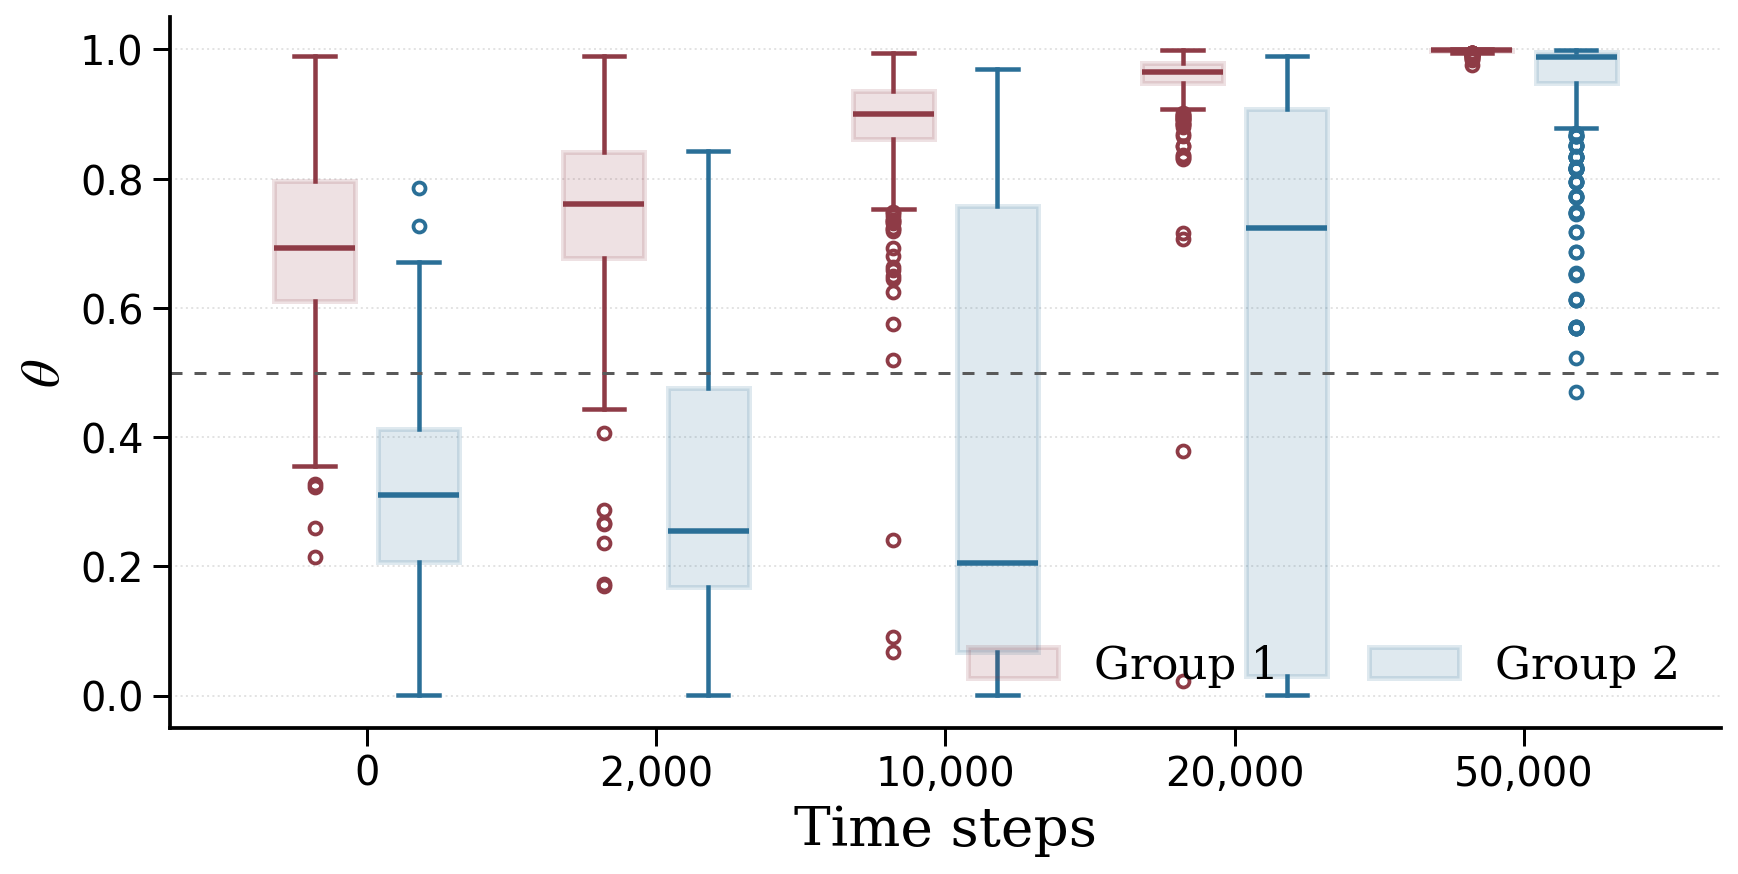

In [77]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta")

------------------------------

# Outcome Feedback Loop (x fijo)

In [78]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [79]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

error_T_g1 = {}
error_T_g2 = {}

A_init = [u.group for u in population]
        
# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x
    
    # Normal outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # Aplicamos outcome Feedback Loop
    outcome_bias = 0.2
    if d == 0 and outcome == 1:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta - outcome_bias))/0.05, (1- (theta - outcome_bias))/0.05, 
                        loc=theta - outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
    elif d == 1 and outcome == 0:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta + outcome_bias))/0.05, (1- (theta + outcome_bias))/0.05, 
                        loc=theta + outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    X = np.append(X, [[x]], axis=0)
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # guardo error de predicción (y.pred_proba - theta en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error_outcomefl(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2

model_init = copy.deepcopy(initial_model)
X_init = copy.deepcopy(X_start)
y_init = copy.deepcopy(y_start)

x_grid, y_pred_init = get_initial_predict_curve(model_init)
plot_data = estimate_plot_curves(population, model)

plot_data["y_pred_init"] = y_pred_init
plot_data["X_init"] = X_init
plot_data["y_init"] = y_init

In [80]:
print(count_d0, count_d1)

25118 24883


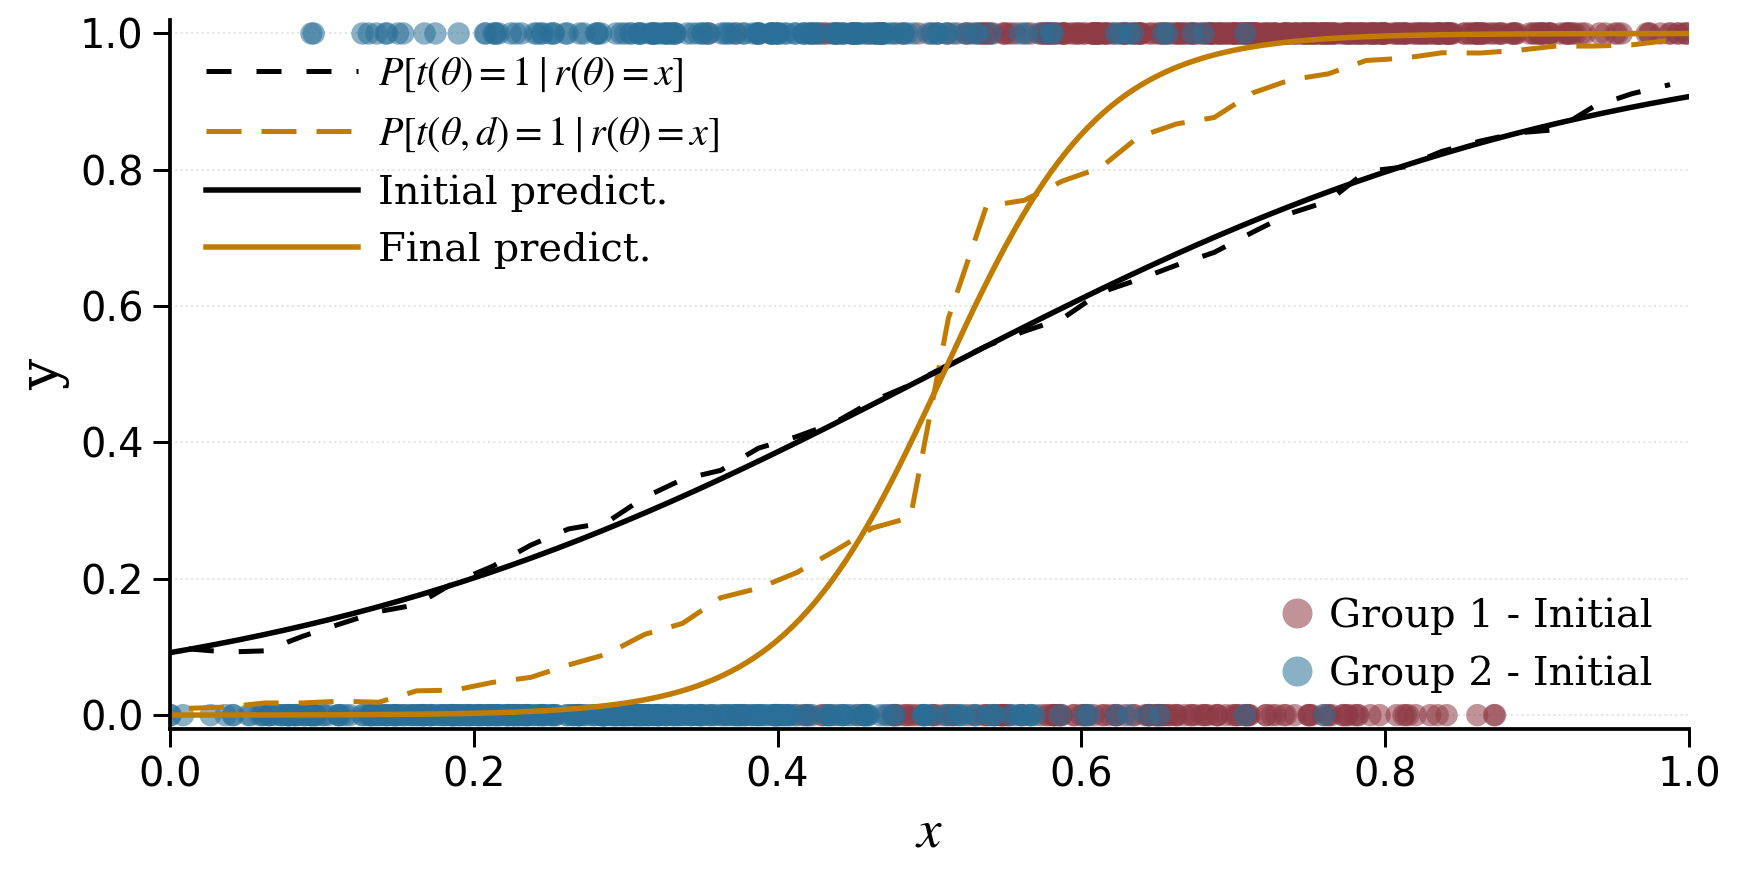

In [81]:
plot_curves(plot_data, A_init=A_init) 

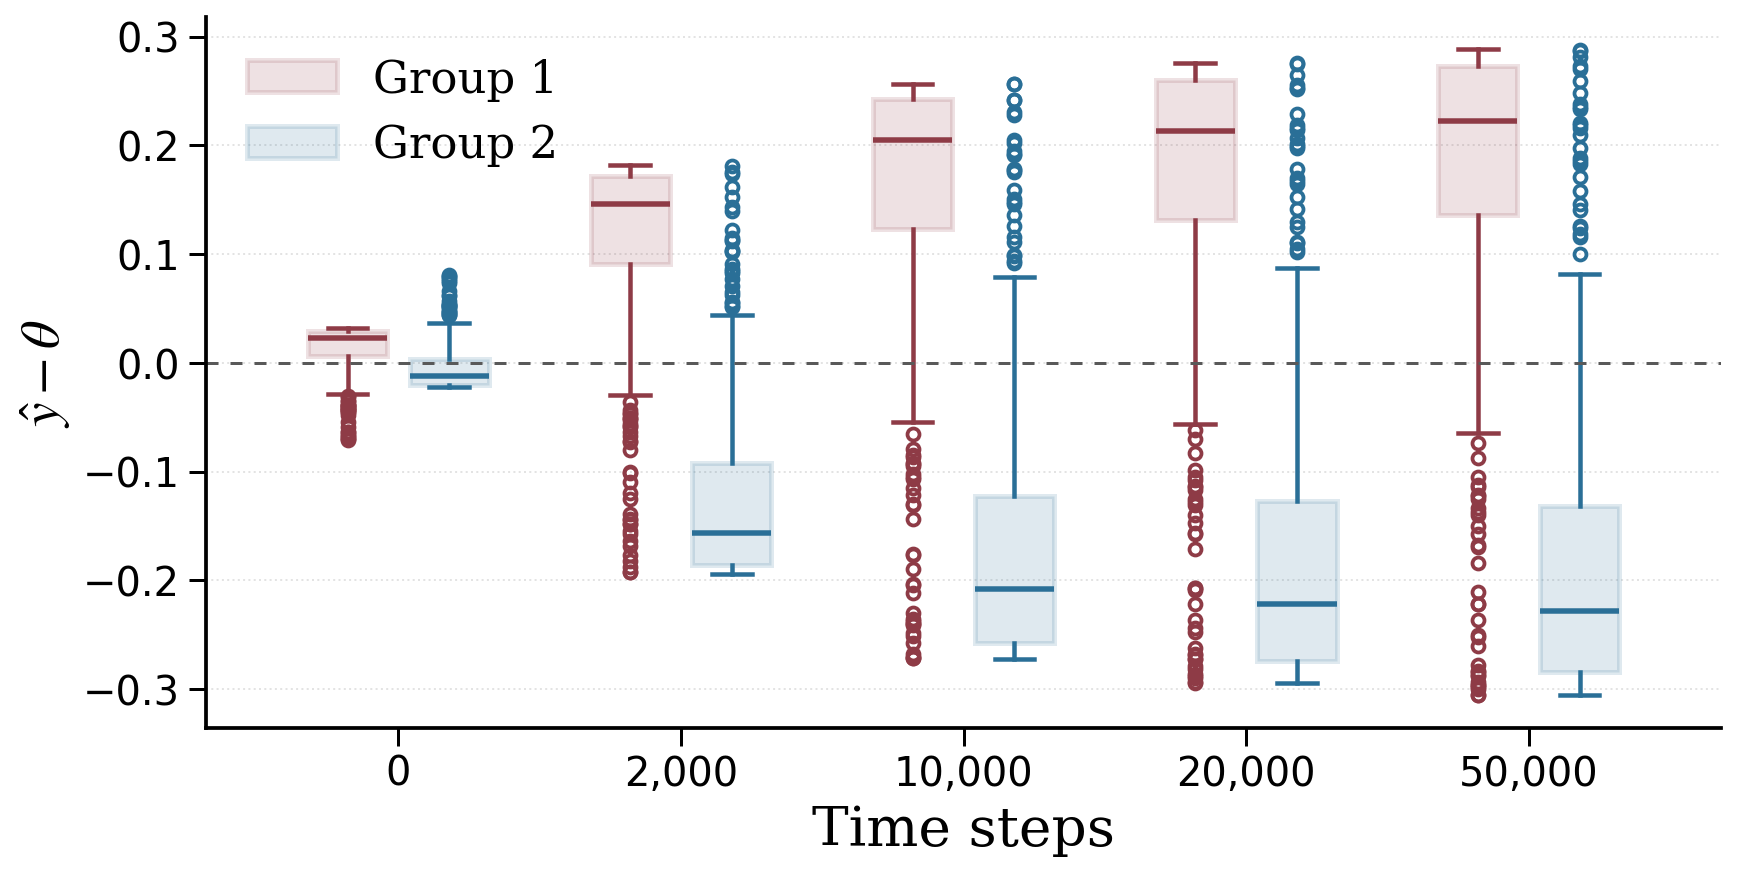

In [82]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error_outcomefl", "upper left", 1)

# Outcome Feedback Loop (x=theta)

In [83]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [84]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

error_T_g1 = {}
error_T_g2 = {}

A_init = [u.group for u in population]
        
# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta      #!!!!
    
    # Normal outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # Aplicamos outcome Feedback Loop
    outcome_bias = 0.2
    if d == 0 and outcome == 1:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta - outcome_bias))/0.05, (1- (theta - outcome_bias))/0.05, 
                        loc=theta - outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
    elif d == 1 and outcome == 0:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta + outcome_bias))/0.05, (1- (theta + outcome_bias))/0.05, 
                        loc=theta + outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    X = np.append(X, [[user.theta]], axis=0)        # !!!
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # guardo error de predicción (y.pred_proba - theta en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error_outcomefl(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2

model_init = copy.deepcopy(initial_model)
X_init = copy.deepcopy(X_start)
y_init = copy.deepcopy(y_start)

x_grid, y_pred_init = get_initial_predict_curve(model_init)
plot_data = estimate_plot_curves(population, model)

plot_data["y_pred_init"] = y_pred_init
plot_data["X_init"] = X_init
plot_data["y_init"] = y_init

In [85]:
print(count_d0, count_d1)

24795 25206


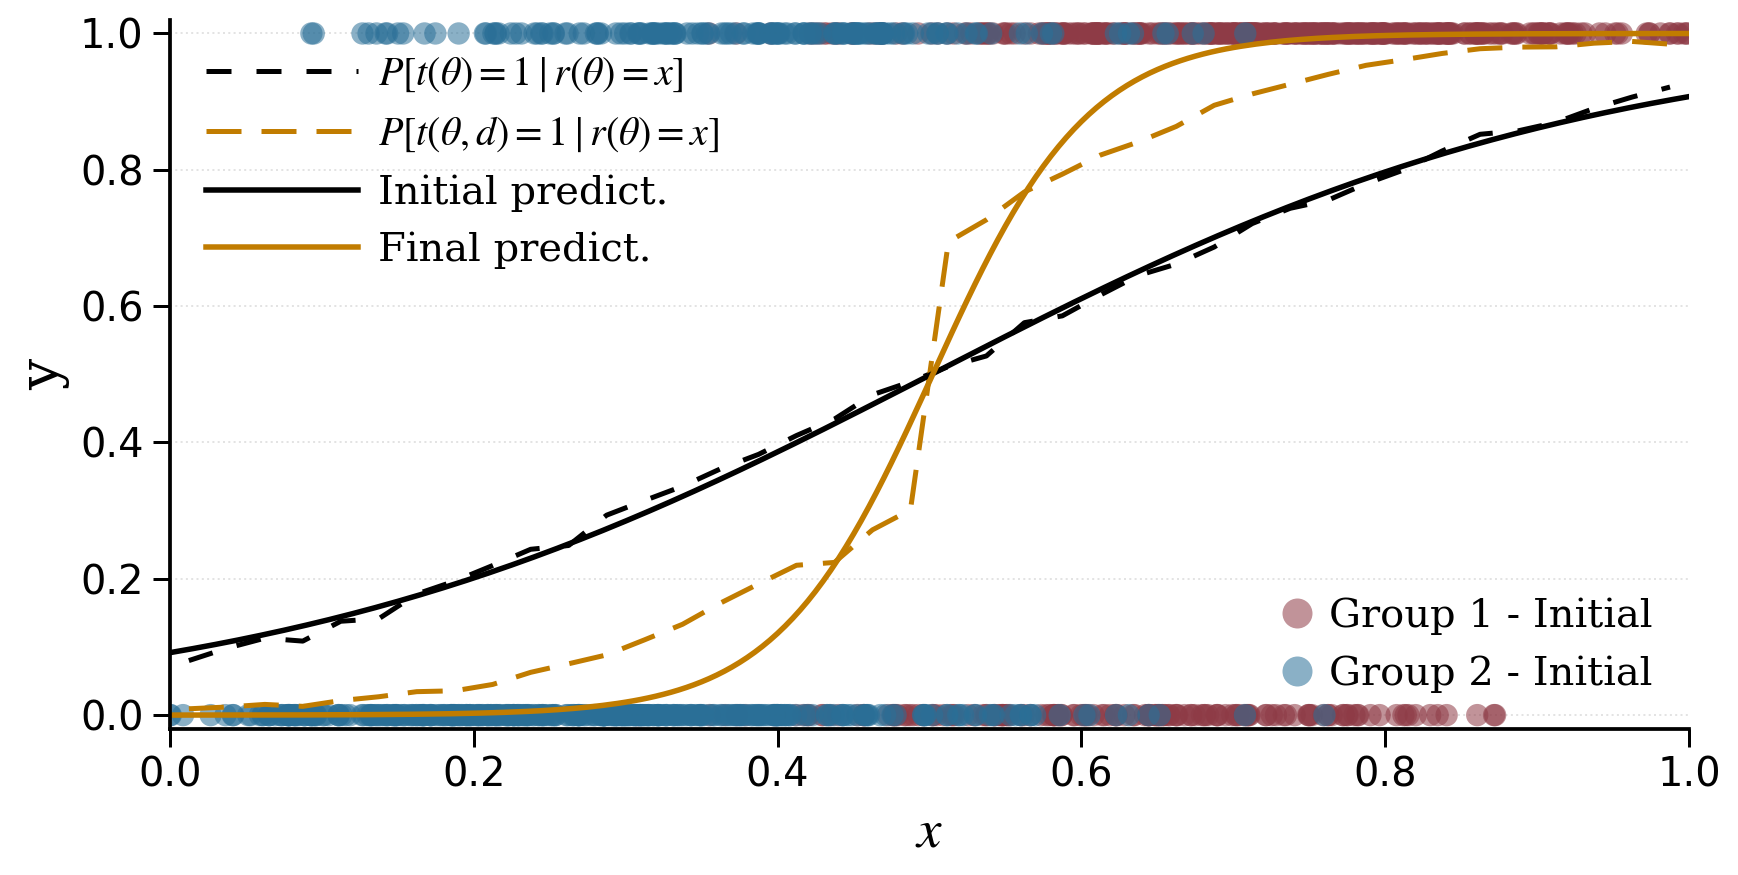

In [86]:
plot_curves(plot_data, A_init=A_init) 

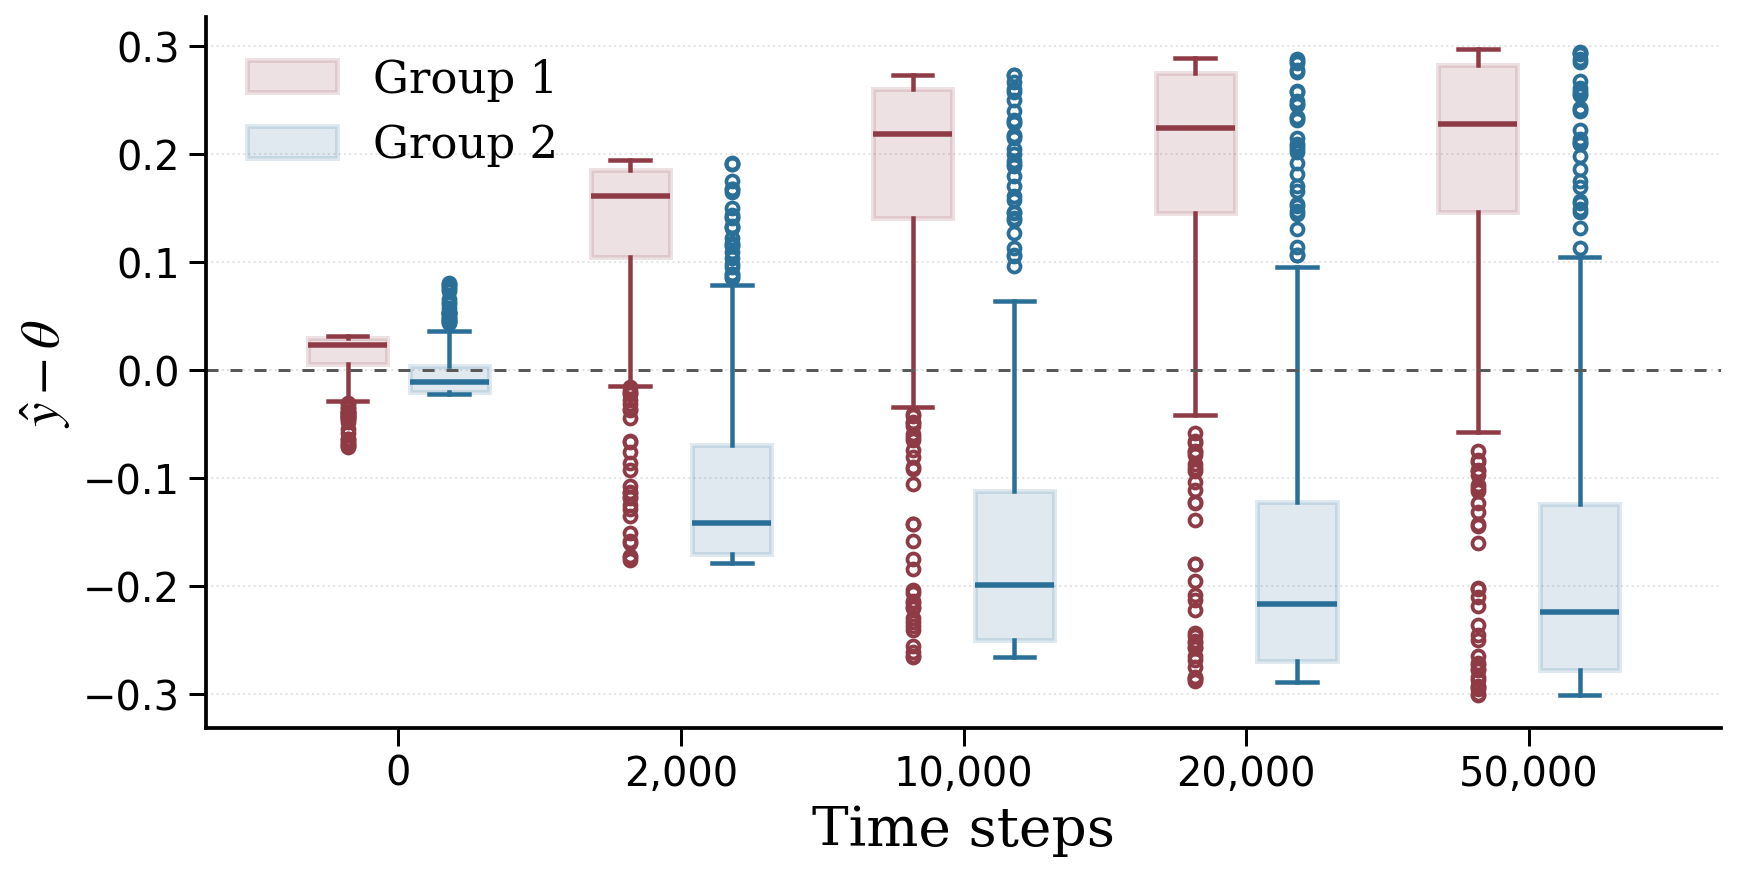

In [87]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error_outcomefl", "upper left", 1)

# Coupled Outcome-Individual Feedback Loop (x fijo)

In [88]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [89]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

theta_T_g1 = {}
theta_T_g2 = {}

error_T_g1 = {}
error_T_g2 = {}

A_init = [u.group for u in population]
        
# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.x      #!!!!   user.theta
    
    # Normal outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # Aplicamos outcome e individual acoplados
    outcome_bias = 0.2
    if d == 0 and outcome == 1:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta - outcome_bias))/0.05, (1- (theta - outcome_bias))/0.05, 
                        loc=theta - outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
        user.theta = min(1, max(0, 0.9*theta))
    elif d == 1 and outcome == 0:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta + outcome_bias))/0.05, (1- (theta + outcome_bias))/0.05, 
                        loc=theta + outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
    elif d == 0 and outcome == 0:
        user.theta = min(1, max(0, 0.9*theta))
    elif d== 1 and outcome == 1:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
        
        
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    X = np.append(X, [[x]], axis=0)         #!!!! user.theta
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # guardo error de predicción (y.pred_proba - theta en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error_outcomefl(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
    
       # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [90]:
print(count_d0, count_d1)

25297 24704


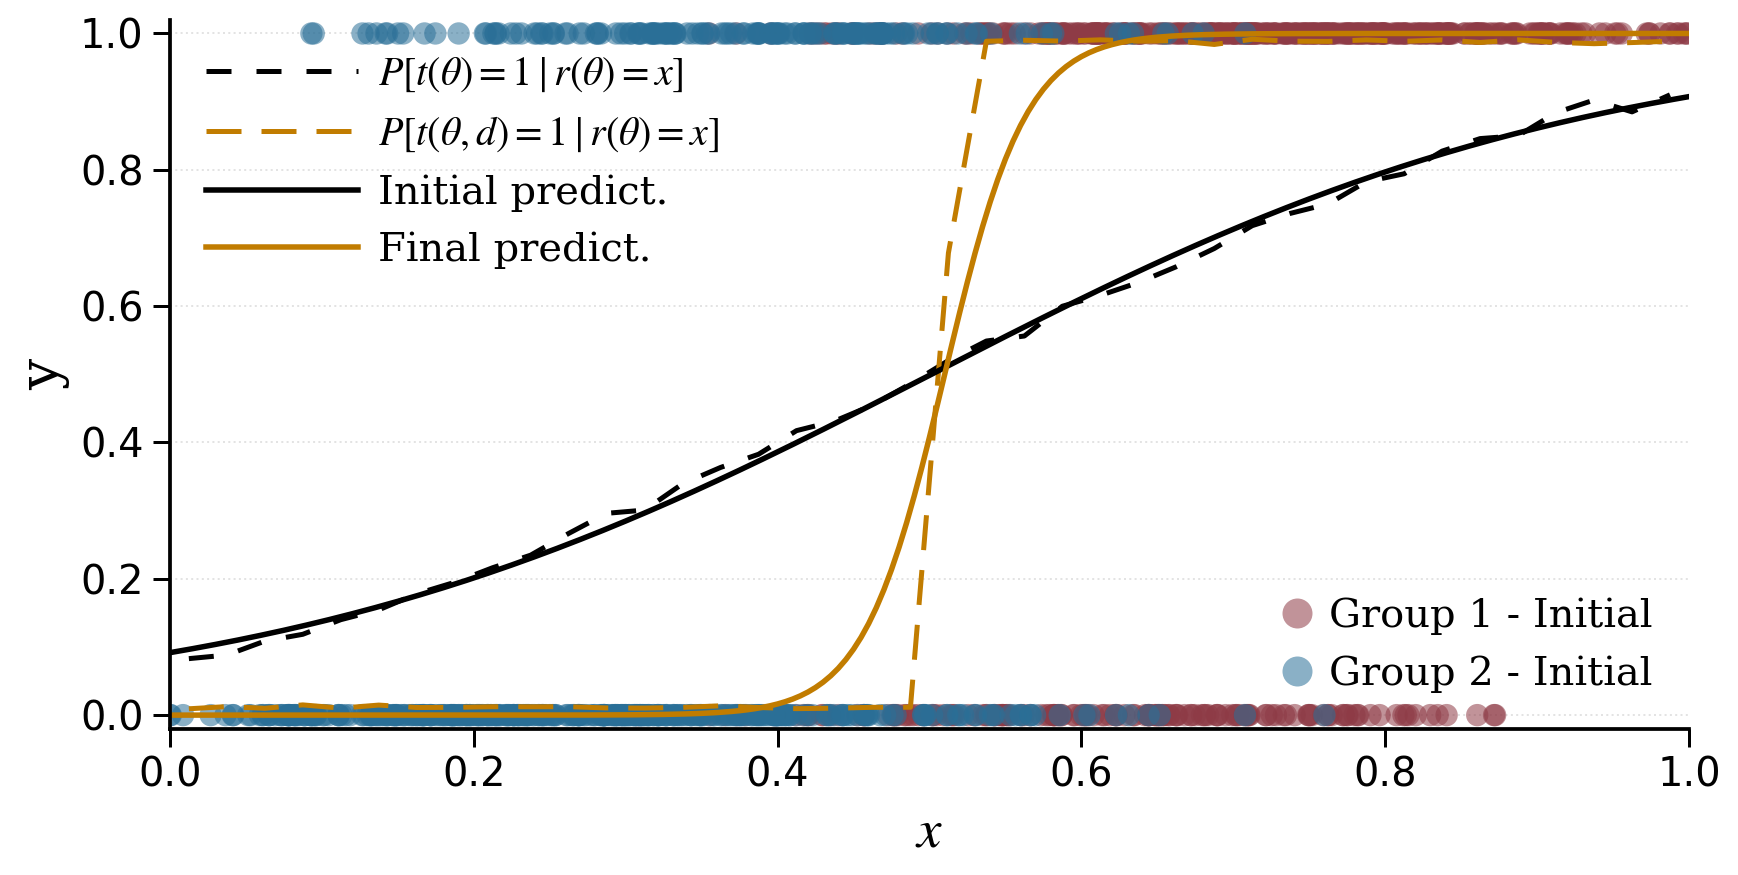

In [91]:
model_init = copy.deepcopy(initial_model)
X_init = copy.deepcopy(X_start)
y_init = copy.deepcopy(y_start)
population_init = copy.deepcopy(initial_population)

x_grid, y_pred_init = get_initial_predict_curve(model_init)

bin_centers_base, y_base_curve = estimate_base_curve(population_init)
plot_data = estimate_plot_curves2(population, model)

plot_data["y_pred_init"] = y_pred_init
plot_data["X_init"] = X_init
plot_data["y_init"] = y_init
plot_data["y_base_curve"] = y_base_curve
plot_data["bin_centers"] = bin_centers_base   # para que plot_curves use esta

plot_curves(plot_data, A_init=A_init)

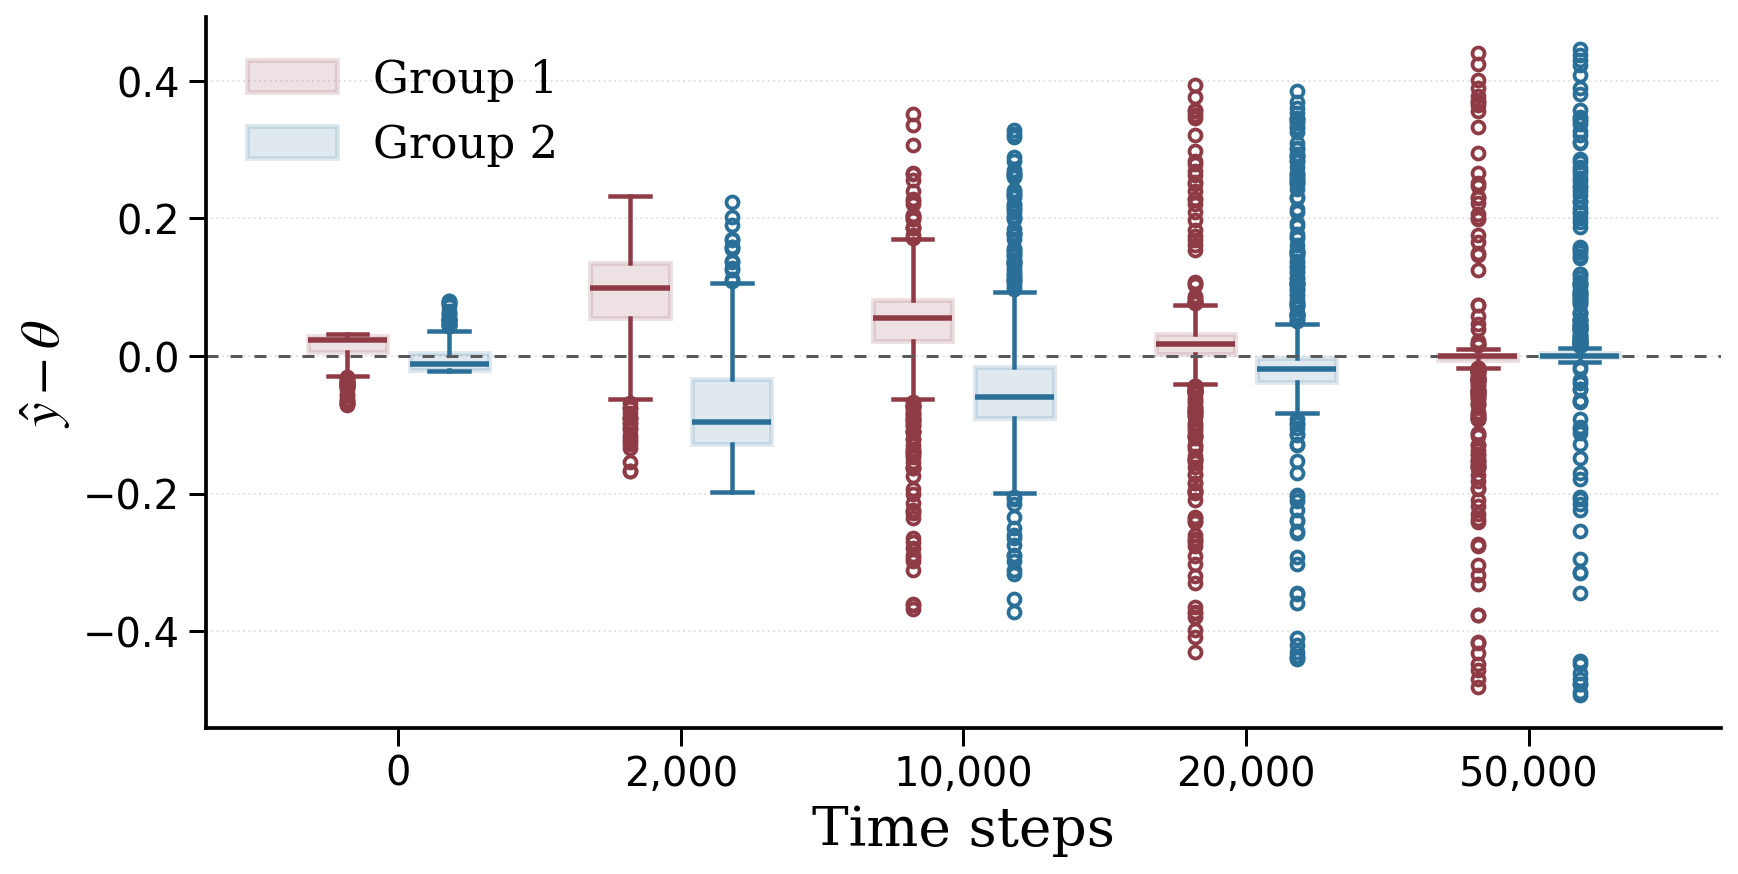

In [92]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error_outcomefl", "upper left", 1)

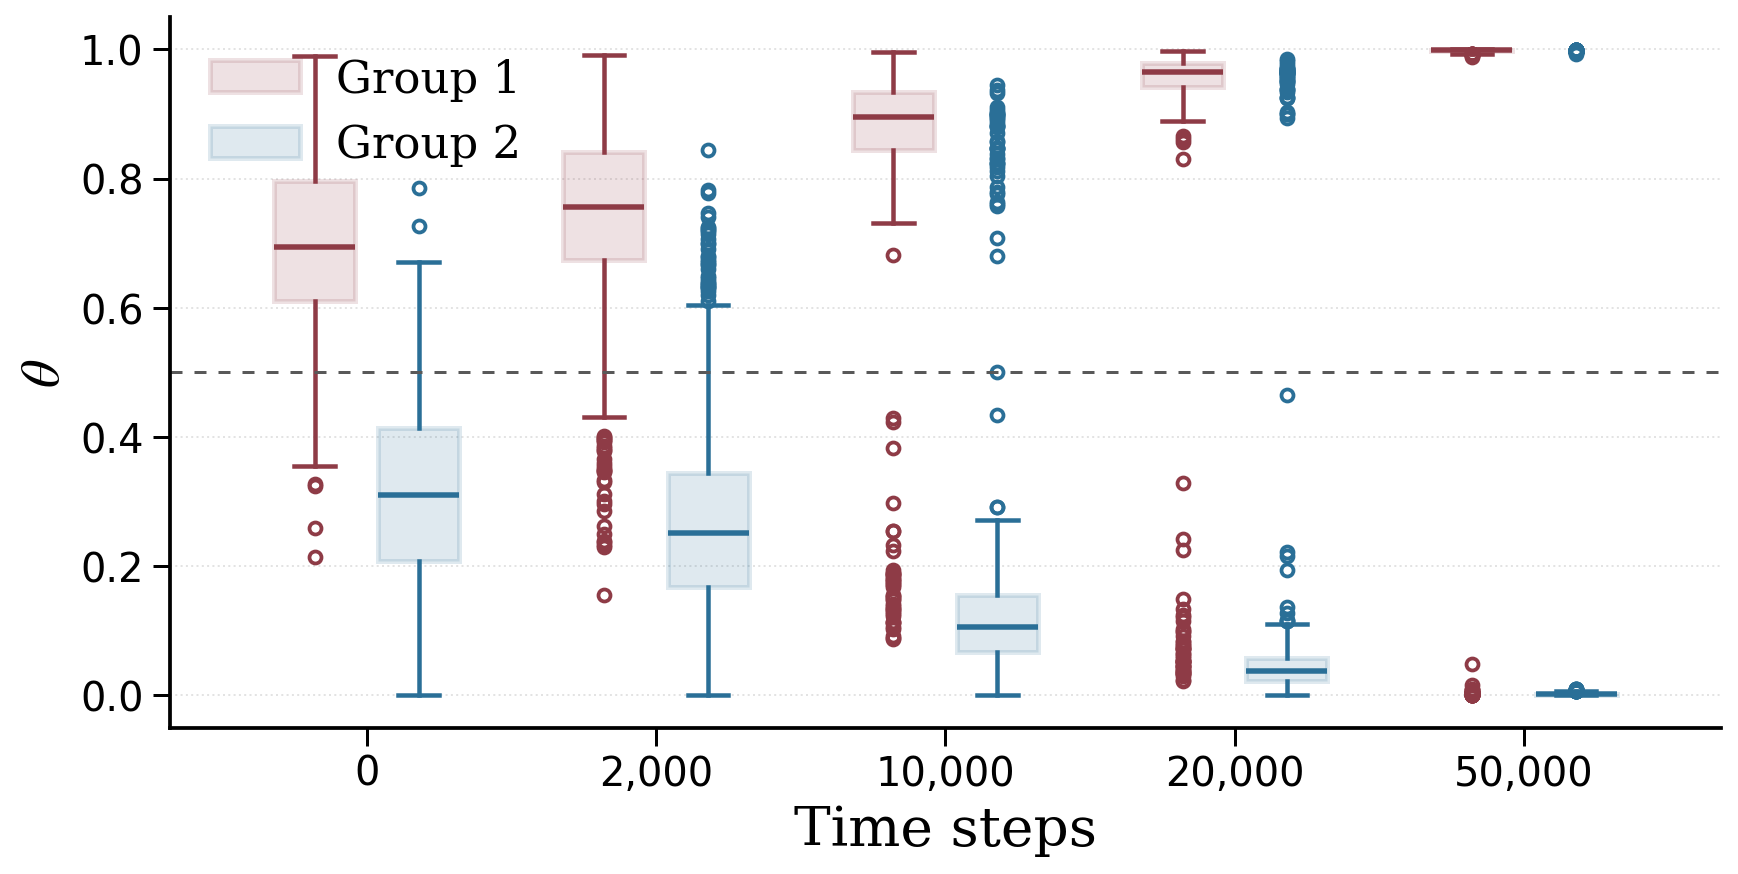

In [93]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "upper left", 1)

# Coupled Individual-Outcome Feedback Loop (x = theta)

In [94]:
X = copy.deepcopy(X_start)
y = copy.deepcopy(y_start)
model = copy.deepcopy(initial_model)
population = copy.deepcopy(initial_population)

In [95]:
# Simulación Sampling Feedback Loop
T = 50000
checkpoints = [0, 2000, 10000, 20000, T]

theta_T_g1 = {}
theta_T_g2 = {}

error_T_g1 = {}
error_T_g2 = {}

A_init = [u.group for u in population]
        
# Variables que creo para análisis:
    # Número de veces que decision es 0 o 1.
count_d1 = 0        
count_d0 = 0

for i in range(0, T + 1):
    user = random.choice(population)
    group = user.group
    user_id = user.user_id
    theta = user.theta
    x = user.theta      #!!!
    
    # Normal outcome realization
    p = truncnorm.rvs((0-theta)/0.1, (1-theta)/0.1, loc=theta, scale=0.1) # p sigue una N(theta, std =0.1), hay, por tanto, ruido (con std 0.1) en el outcome realization
    outcome = np.random.binomial(1, p)
    
    # model prediction and decision
    y_hat = model.predict([[x]])[0]
    d = y_hat       # por defecto y_hat trunca a 1 cuando >0.5
    
    # Aplicamos outcome e individual acoplados
    outcome_bias = 0.2
    if d == 0 and outcome == 1:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta - outcome_bias))/0.05, (1- (theta - outcome_bias))/0.05, 
                        loc=theta - outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
        user.theta = min(1, max(0, 0.9*theta))
    elif d == 1 and outcome == 0:
        # re-muestreo y (detalle importante: pagan usa std de 0.05 aquí, en lugar de 1)
        p = truncnorm.rvs((0- (theta + outcome_bias))/0.05, (1- (theta + outcome_bias))/0.05, 
                        loc=theta + outcome_bias, scale=0.05)
        outcome = np.random.binomial(1, p)
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
    elif d == 0 and outcome == 0:
        user.theta = min(1, max(0, 0.9*theta))
    elif d== 1 and outcome == 1:
        user.theta = min(1, max(0, 0.1 + 0.9*theta))
        
        
    
    count_d1 += (d == 1)   
    count_d0 += (d == 0)
    
    X = np.append(X, [[user.theta]], axis=0)         #!!!! 
    y = np.append(y, outcome)
    
    # reentreno el modelo
    model = train_LR(X, y)
    
    # guardo error de predicción (y.pred_proba - theta en checkpoints
    if i in checkpoints:
        err_g1, err_g2 = error_outcomefl(population, model)
        error_T_g1[i] = err_g1
        error_T_g2[i] = err_g2
    
       # guardo distribución de thetas por grupo cada cierto número de time steps
    if i in checkpoints:
        theta_T_g1[i] = [u.theta for u in population if u.group == 1]
        theta_T_g2[i] = [u.theta for u in population if u.group == 2]

In [96]:
print(count_d0, count_d1)

25070 24931


In [97]:
model_init = copy.deepcopy(initial_model)
X_init = copy.deepcopy(X_start)
y_init = copy.deepcopy(y_start)
population_init = copy.deepcopy(initial_population)

x_grid, y_pred_init = get_initial_predict_curve(model_init)

bin_centers_base, y_base_curve = estimate_base_curve(population_init)
plot_data = estimate_plot_curves2(population, model)

plot_data["y_pred_init"] = y_pred_init
plot_data["X_init"] = X_init
plot_data["y_init"] = y_init
plot_data["y_base_curve"] = y_base_curve
plot_data["bin_centers"] = bin_centers_base   # para que plot_curves use esta

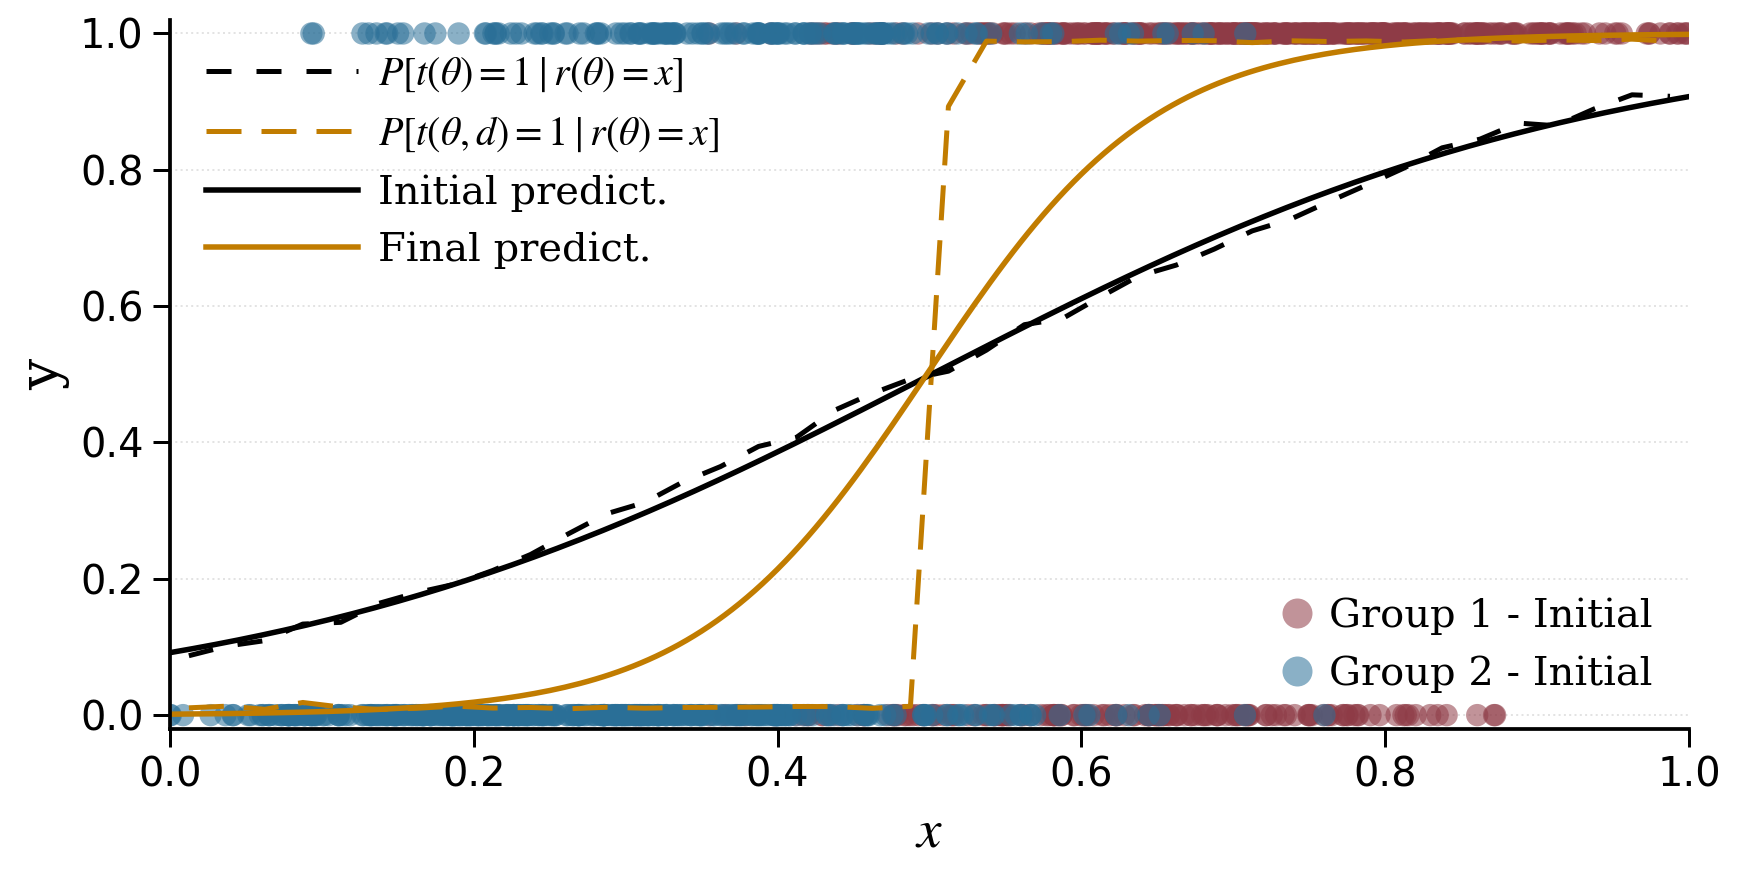

In [98]:
plot_curves(plot_data, A_init=A_init) 

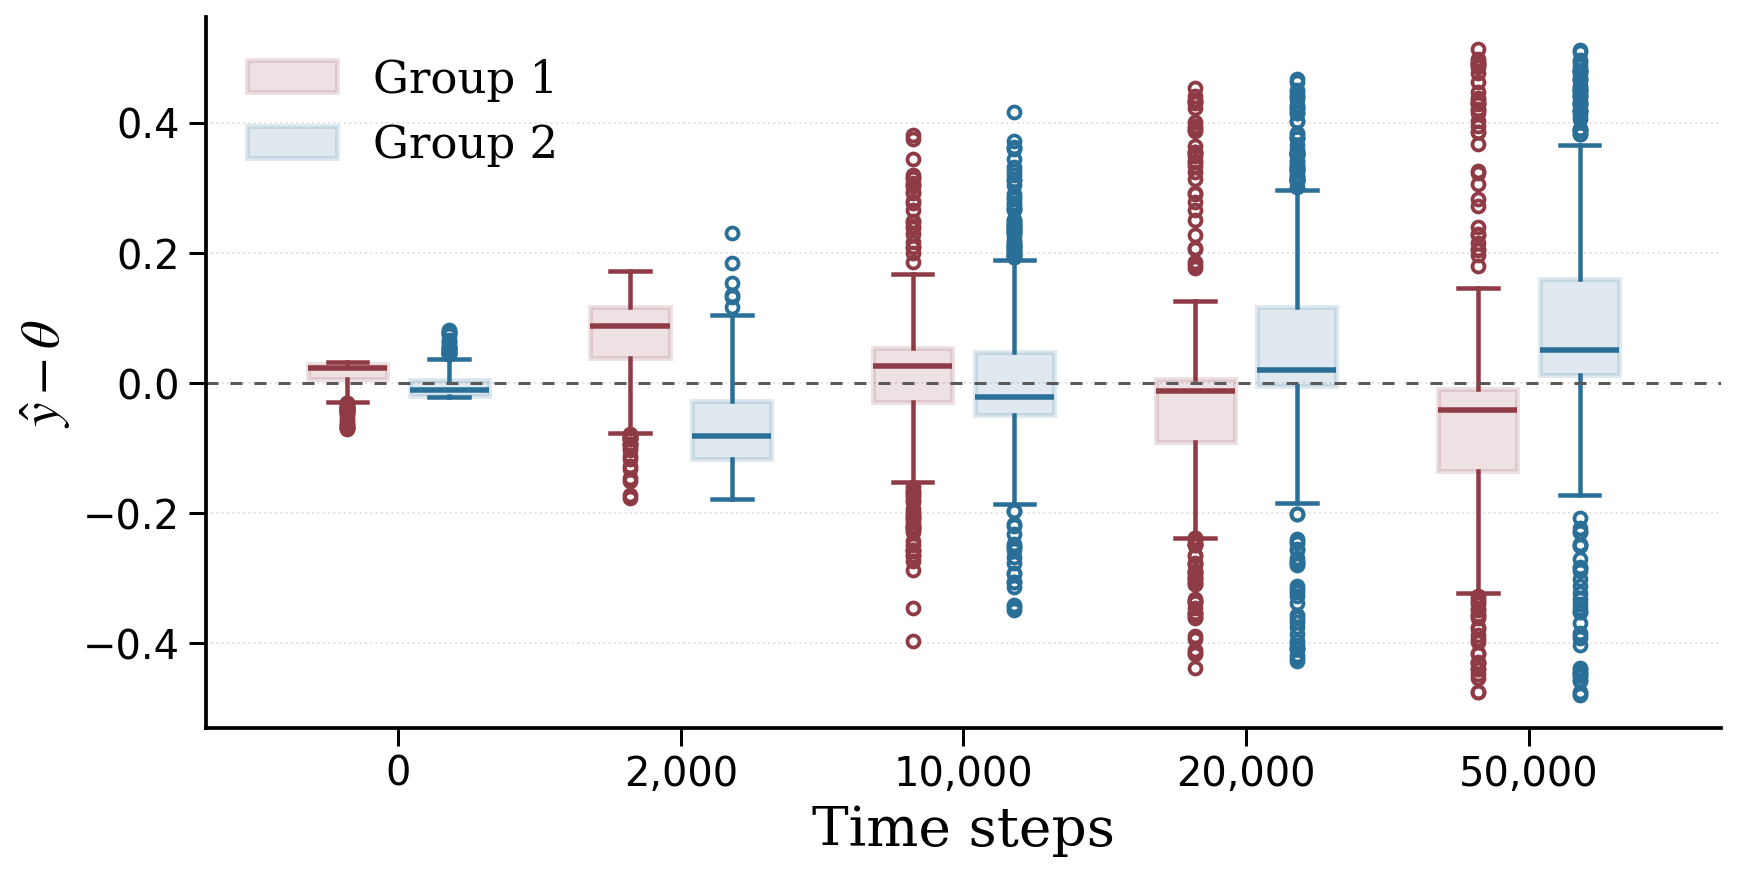

In [99]:
plot_boxplots(error_T_g1, error_T_g2, checkpoints, "error_outcomefl", "upper left", 1)

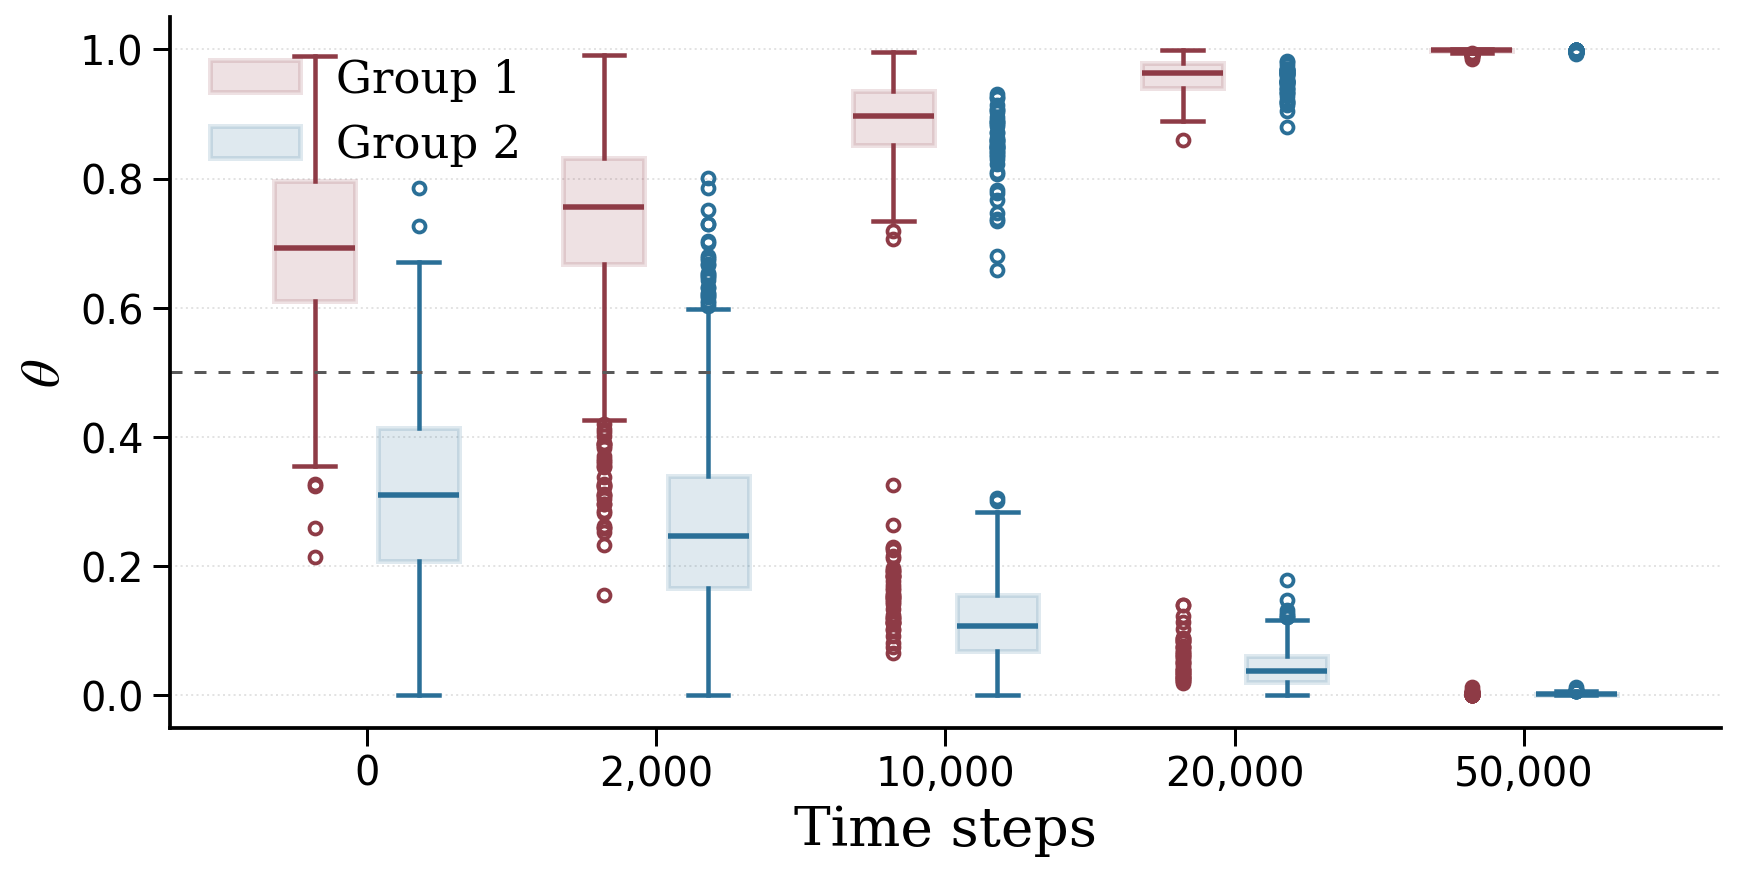

In [100]:
plot_boxplots(theta_T_g1, theta_T_g2, checkpoints, "theta", "upper left", 1)